<a href="https://colab.research.google.com/github/AngurisSummer/Informatik-Bullet-Time/blob/main/Bullet_Time_Interpolierungscode.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Bullet-Time — YOLO Person + AI Object Detection + SAM

This Colab is designed for a 29-camera bullet-time capture.

- **YOLO segmentation** isolates the main person.
- **Grounding DINO** independently detects a text-described everyday object in every camera (default: `paper airplane`).
- **SAM** converts each detected object box into a precise object mask.
- The person and object masks are combined into one transparent foreground.
- Object masks are **not propagated by optical flow**, so one bad camera cannot corrupt all later cameras.
- Mild subject stabilization uses the **person only**, so a moving paper plane does not change the framing.
- The first diagnostic export uses the **29 real cameras only**. No synthetic inter-camera frames are generated yet.

Use an **A100** if available; a T4 also works but will be slower.

**Colab compatibility fix:** this version repairs Pillow cleanly and restarts the runtime once to prevent mixed-version `PIL._typing` / `ImageText` import errors.


## 1. Install

In [ ]:
# ==========================================================
# COLAB-SAFE DEPENDENCY SETUP
# ==========================================================
# Why this exists:
# Colab may already have Pillow imported internally. Upgrading Pillow in-place
# can mix files from two Pillow versions and cause:
#   ImportError: cannot import name '_Ink' from 'PIL._typing'
#
# This cell installs a known-good Pillow build, then restarts the Python
# process ONCE so every PIL module is loaded from the same version.

from pathlib import Path
import os
import subprocess
import sys

SETUP_MARKER = Path("/content/.bullet_time_ai_dependencies_v3")

if not SETUP_MARKER.exists():
    print("Preparing a clean Colab environment...")

    # Install Pillow first and force a coherent installation.
    subprocess.check_call([
        sys.executable, "-m", "pip", "install",
        "-q", "--no-cache-dir", "--force-reinstall",
        "Pillow==11.3.0"
    ])

    # Do NOT use '-U pillow' here.
    subprocess.check_call([
        sys.executable, "-m", "pip", "install",
        "-q", "--no-cache-dir",
        "ultralytics",
        "transformers>=4.52,<5",
        "accelerate",
        "opencv-python-headless",
        "pandas==2.2.3"
    ])

    SETUP_MARKER.write_text("installed", encoding="utf-8")

    print()
    print("Dependencies installed successfully.")
    print("Restarting the Python runtime once to clear old Pillow modules...")
    print("After Colab reconnects, choose Runtime > Run all.")
    os.kill(os.getpid(), 9)

else:
    print("Dependencies already prepared for this runtime.")
    print("Continuing without reinstalling Pillow.")


Dependencies already prepared for this runtime.
Continuing without reinstalling Pillow.


In [ ]:
# ==========================================================
# INSTALL RIFE
# ==========================================================

%cd /content

!rm -rf ECCV2022-RIFE
!git clone -q https://github.com/hzwer/ECCV2022-RIFE.git

%cd /content/ECCV2022-RIFE

!pip install -q -r requirements.txt

print("RIFE repository ready.")

/content
/content/ECCV2022-RIFE
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 154.3 MB/s eta 0:00:00
  Installing build dependencies ... done
  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Getting requirements to build wheel ... error
error: subprocess-exited-with-error

× Getting requirements to build wheel did not run successfully.
│ exit code: 1
╰─> See above for output.

note: This error originates from a subprocess, and is likely not a problem with pip.
RIFE repository ready.


In [ ]:
# ==========================================================
# DOWNLOAD RIFE MODEL
# ==========================================================

%cd /content/ECCV2022-RIFE

!pip install -q huggingface_hub

from huggingface_hub import hf_hub_download
import zipfile
from pathlib import Path
import shutil

MODEL_ZIP = hf_hub_download(
    repo_id="Bash2X/RIFE-Models",
    filename="RIFE_v4.22.lite.zip"
)

RIFE_MODEL_DIR = Path("/content/ECCV2022-RIFE/train_log")

shutil.rmtree(
    RIFE_MODEL_DIR,
    ignore_errors=True
)

RIFE_MODEL_DIR.mkdir(
    parents=True,
    exist_ok=True
)

with zipfile.ZipFile(MODEL_ZIP, "r") as z:
    z.extractall(RIFE_MODEL_DIR)

print(
    "RIFE model downloaded to:",
    RIFE_MODEL_DIR
)

/content/ECCV2022-RIFE


/usr/local/lib/python3.13/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


RIFE_v4.22.lite.zip:   0%|          | 0.00/19.9M [00:00<?, ?B/s]

RIFE model downloaded to: /content/ECCV2022-RIFE/train_log


In [ ]:
# ==========================================================
# FIX RIFE MODEL WEIGHTS
# ==========================================================

%cd /content/ECCV2022-RIFE

!rm -rf train_log
!mkdir -p train_log

# Download model weights known to work with the repo structure.
!wget -q https://github.com/hzwer/ECCV2022-RIFE/releases/download/4.6/train_log.zip \
    -O /content/train_log.zip

!unzip -q /content/train_log.zip -d /content/ECCV2022-RIFE/

print("Contents of train_log:")
!find /content/ECCV2022-RIFE/train_log -maxdepth 2 -type f | head -30

/content/ECCV2022-RIFE
[/content/train_log.zip]
  End-of-central-directory signature not found.  Either this file is not
  a zipfile, or it constitutes one disk of a multi-part archive.  In the
  latter case the central directory and zipfile comment will be found on
  the last disk(s) of this archive.
unzip:  cannot find zipfile directory in one of /content/train_log.zip or
        /content/train_log.zip.zip, and cannot find /content/train_log.zip.ZIP, period.
Contents of train_log:


In [ ]:
print('Checking Pillow installation:')
!pip show Pillow

Checking Pillow installation:
Name: pillow
Version: 11.3.0
Summary: Python Imaging Library (Fork)
Home-page: https://python-pillow.github.io
Author: 
Author-email: "Jeffrey A. Clark" <aclark@aclark.net>
License: 
Location: /usr/local/lib/python3.13/dist-packages
Requires: 
Required-by: bokeh, diffusers, dopamine_rl, fastai, gradio, ImageIO, matplotlib, scikit-image, tensorboard, torchtune, torchvision, ultralytics, wordcloud


In [ ]:
import os
import re
import math
import time
import shutil
import zipfile

from pathlib import Path
from contextlib import nullcontext
from collections import defaultdict, Counter

import numpy as np
import pandas as pd
import cv2
import torch

import PIL
from PIL import Image, ImageFont

from ultralytics import YOLO

from transformers import (
    AutoProcessor,
    AutoModelForZeroShotObjectDetection,
    SamModel,
    SamProcessor,
)

from IPython.display import display, HTML

Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart#ultralytics-settings.


The installation cell intentionally restarts the Python process once. After Colab reconnects, use **Runtime → Run all**. The marker prevents a second restart.


In [ ]:
# No duplicate environment imports are needed here.
print('Environment check complete.')


Environment check complete.


## 2. Imports and settings

In [ ]:
# Defensive Pillow check.
# Import Pillow modules the supported way.
try:
    from PIL import Image, ImageFont
    import PIL
except Exception as e:
    raise RuntimeError(
        "Pillow could not be imported cleanly. "
        "Run the dependency setup cell once, allow the automatic runtime restart, "
        "then use Runtime > Run all."
    ) from e

print("Pillow import OK:", PIL.__version__)



Pillow import OK: 11.3.0


In [ ]:
# ==========================================================
# MAIN SETTINGS TO CHANGE BETWEEN EXPERIMENTS
# ==========================================================

# Type the everyday object here.
TARGET_OBJECT = "paper airplane"

# Give the open-vocabulary detector several natural descriptions.
TARGET_PROMPT = (
    "paper airplane. "
    "paper plane. "
    "folded paper airplane. "
    "flying paper airplane."
)

# Lower these slightly if the object is missed; raise if false positives appear.
OBJECT_BOX_THRESHOLD = 0.20
OBJECT_TEXT_THRESHOLD = 0.18

# Keep the first diagnostic conservative.
INTERPOLATIONS_BETWEEN_CAMERAS = 0
FPS = 24

print("Target object:", TARGET_OBJECT)
print("Prompt:", TARGET_PROMPT)
print("Real-camera output FPS:", FPS)

Target object: paper airplane
Prompt: paper airplane. paper plane. folded paper airplane. flying paper airplane.
Real-camera output FPS: 24


## 3. Upload ZIP and sort cameras

In [ ]:
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


In [ ]:
from pathlib import Path

ZIP_PATH = Path(
    "/content/drive/MyDrive/Ergebnisse 03.08.2026.zip"
)

print("ZIP exists:", ZIP_PATH.exists())
print(ZIP_PATH)

ZIP exists: True
/content/drive/MyDrive/Ergebnisse 03.08.2026.zip


In [ ]:
import zipfile
import shutil
import time
from pathlib import Path

EXTRACT_DIR = Path("/content/bullet_time_capture")

if EXTRACT_DIR.exists():
    shutil.rmtree(EXTRACT_DIR)

EXTRACT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

start = time.time()

with zipfile.ZipFile(
    ZIP_PATH,
    "r"
) as z:
    z.extractall(
        EXTRACT_DIR
    )

print(
    f"Extraction finished in "
    f"{time.time() - start:.1f} seconds"
)

print("Extracted to:")
print(EXTRACT_DIR)

Extraction finished in 10.0 seconds
Extracted to:
/content/bullet_time_capture


In [ ]:
import re

SUPPORTED_IMAGE_EXTENSIONS = {
    ".jpg",
    ".jpeg",
    ".png",
    ".webp",
    ".jfif"
}

CAMERA_REGEX = r"Kamera[_ -]?(\d+)"

camera_items = []

for path in EXTRACT_DIR.rglob("*"):

    if (
        path.is_file()
        and path.suffix.lower()
        in SUPPORTED_IMAGE_EXTENSIONS
    ):

        match = re.search(
            CAMERA_REGEX,
            path.name,
            re.IGNORECASE
        )

        if match:

            number = int(
                match.group(1)
            )

            camera_items.append(
                (
                    number,
                    path
                )
            )


camera_items.sort(
    key=lambda x: x[0]
)

CAMERA_NUMBERS = [
    number
    for number, path
    in camera_items
]

CAMERA_PATHS = [
    path
    for number, path
    in camera_items
]


print(
    "Found",
    len(CAMERA_PATHS),
    "camera images"
)

print(
    "Camera order:",
    CAMERA_NUMBERS
)

Found 350 camera images
Camera order: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 17, 17, 17, 17, 17, 17, 17, 17, 17, 17, 17, 17, 18, 18, 18, 18, 18, 18, 18, 18, 18, 18, 18, 18, 19, 19, 19, 19, 19, 19, 19, 19, 19, 19, 19, 19, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 21, 21, 21, 21, 21, 21, 21, 21, 21, 21, 21, 21, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 23, 23, 23, 23, 2

In [ ]:
# ============================================================
# GROUP THE IMAGES INTO SEPARATE 29-CAMERA CAPTURES
# Run this directly after the previous camera-search block
# ============================================================

from collections import defaultdict, Counter

capture_groups = defaultdict(list)

# Group the camera images according to the folder
# they came from inside the ZIP.
for number, path in camera_items:

    # Usually the structure is:
    # Aufnahme_xxx / Bilder / Kamera_xx.jpg
    #
    # Using the parent folder of "Bilder" separates
    # the different captures.
    if path.parent.name.lower() == "bilder":
        capture_folder = path.parent.parent
    else:
        capture_folder = path.parent

    capture_groups[capture_folder].append(
        (number, path)
    )


# Sort each capture internally:
# Camera 1 -> Camera 2 -> ... -> Camera 29
for folder in capture_groups:
    capture_groups[folder].sort(
        key=lambda x: x[0]
    )


# Sort captures by folder name
capture_list = sorted(
    capture_groups.items(),
    key=lambda x: str(x[0])
)


print(f"Found {len(capture_list)} separate capture folders.\n")


# Show what is inside each capture
for i, (folder, images) in enumerate(capture_list):

    numbers = [
        number
        for number, path in images
    ]

    counts = Counter(numbers)

    duplicates = [
        number
        for number, count in counts.items()
        if count > 1
    ]

    missing = [
        number
        for number in range(1, 30)
        if number not in numbers
    ]

    clean = (
        len(images) == 29
        and not duplicates
        and not missing
    )

    status = "✓ CLEAN 29-CAMERA SET" if clean else "⚠ CHECK"

    print(
        f"[{i}] {folder.name}"
    )

    print(
        f"    Images: {len(images)}"
    )

    print(
        f"    Cameras: {numbers}"
    )

    print(
        f"    Missing: {missing if missing else 'None'}"
    )

    print(
        f"    Duplicates: {duplicates if duplicates else 'None'}"
    )

    print(
        f"    {status}\n"
    )

Found 12 separate capture folders.

[0] Aufnahme_20260903_111659_150
    Images: 1
    Cameras: [23]
    Missing: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 24, 25, 26, 27, 28, 29]
    Duplicates: None
    ⚠ CHECK

[1] Aufnahme_20260903_111740_864
    Images: 1
    Cameras: [23]
    Missing: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 24, 25, 26, 27, 28, 29]
    Duplicates: None
    ⚠ CHECK

[2] Aufnahme_20260903_113846_965
    Images: 1
    Cameras: [29]
    Missing: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28]
    Duplicates: None
    ⚠ CHECK

[3] Aufnahme_20260903_115840_664
    Images: 29
    Cameras: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29]
    Missing: None
    Duplicates: None
    ✓ CLEAN 29-CAMERA SET

[4] Aufnahme_20260903_115926_883
    Images: 28
    Cameras: [1, 2, 3, 4, 5, 6, 7

In [ ]:
# ============================================================
# AUTOMATICALLY SELECT A CLEAN 29-CAMERA CAPTURE
# ============================================================

from collections import Counter

clean_captures = []

for folder, images in capture_list:

    numbers = [
        number
        for number, path in images
    ]

    counts = Counter(numbers)

    duplicates = [
        number
        for number, count in counts.items()
        if count > 1
    ]

    missing = [
        number
        for number in range(1, 30)
        if number not in numbers
    ]

    if (
        len(images) == 29
        and not duplicates
        and not missing
    ):
        clean_captures.append(
            (
                folder,
                sorted(
                    images,
                    key=lambda x: x[0]
                )
            )
        )


print(
    f"Found {len(clean_captures)} clean "
    f"29-camera captures.\n"
)

for i, (folder, images) in enumerate(
    clean_captures
):
    print(
        f"[{i}] {folder.name}"
    )


# ------------------------------------------------------------
# Automatically choose first complete 29-camera capture
# ------------------------------------------------------------

if not clean_captures:
    raise RuntimeError(
        "No complete Camera 1-29 capture found."
    )

selected_folder, camera_items = (
    clean_captures[4]
)

CAMERA_NUMBERS = [
    number
    for number, path
    in camera_items
]

CAMERA_PATHS = [
    path
    for number, path
    in camera_items
]


print()
print("Automatically selected:")
print(selected_folder)

print()
print(
    "Number of images:",
    len(CAMERA_PATHS)
)

print(
    "Camera order:",
    CAMERA_NUMBERS
)

print()
print(
    "✓ Ready for YOLO + SAM processing."
)

Found 7 clean 29-camera captures.

[0] Aufnahme_20260903_115840_664
[1] Aufnahme_20260903_120224_197
[2] Aufnahme_20260903_120252_253
[3] Aufnahme_20260903_120428_395
[4] Aufnahme_20260903_120456_269
[5] Aufnahme_20260903_121917_826
[6] Aufnahme_20260903_122024_097

Automatically selected:
/content/bullet_time_capture/Ergebnisse 03.08.2026/Aufnahme_20260903_120456_269

Number of images: 29
Camera order: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29]

✓ Ready for YOLO + SAM processing.


## 4. Load YOLO, Grounding DINO and SAM

In [ ]:
# ==========================================================
# COMPLETE BULLET-TIME CONFIGURATION
# ==========================================================

# -------------------------
# AI MODELS
# -------------------------

YOLO_MODEL_NAME = "yolo11n-seg.pt"

GROUNDING_DINO_MODEL_ID = "IDEA-Research/grounding-dino-tiny"

SAM_MODEL_ID = "facebook/sam-vit-base"


# -------------------------
# DEVICE
# -------------------------

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"


# -------------------------
# YOLO PERSON SEGMENTATION
# -------------------------

PERSON_CLASS_ID = 0

YOLO_IMGSZ = 1024
YOLO_CONF = 0.25
YOLO_IOU = 0.50


# Restrict the YOLO mask around the detected person.
# This prevents floor/table/background pieces becoming
# part of the person mask.

PERSON_BOX_MARGIN_X = 0.15
PERSON_BOX_MARGIN_TOP = 0.08
PERSON_BOX_MARGIN_BOTTOM = 0.05


# Sanity-check ranges for person geometry

PERSON_HEIGHT_RATIO_MIN = 0.35
PERSON_HEIGHT_RATIO_MAX = 0.98

PERSON_CENTER_ERROR_MAX = 0.35


# -------------------------
# TARGET EVERYDAY OBJECT
# -------------------------

KEEP_EXTRA_OBJECT = True

TARGET_OBJECT = "paper airplane"

TARGET_PROMPT = (
    "paper airplane. "
    "paper plane. "
    "folded paper airplane. "
    "flying paper airplane."
)


# Grounding DINO thresholds

OBJECT_BOX_THRESHOLD = 0.20
OBJECT_TEXT_THRESHOLD = 0.18


# Ignore absurdly small / large DINO detections.
# Ratio is relative to the complete image area.

OBJECT_MIN_AREA_RATIO = 0.00002
OBJECT_MAX_AREA_RATIO = 0.08


# -------------------------
# SAM OBJECT SEGMENTATION
# -------------------------

# Expand DINO box slightly before giving it to SAM

SAM_BOX_MARGIN = 0.10

# After SAM segmentation, restrict resulting mask
# close to the detected object box.

OBJECT_MASK_BOX_EXPANSION = 0.18


# -------------------------
# STABILIZATION
# -------------------------

ENABLE_SUBJECT_STABILIZATION = True

STABILIZATION_STRENGTH = 0.70

MIN_SCALE = 0.985
MAX_SCALE = 1.015


# -------------------------
# FRAME INTERPOLATION
# -------------------------

# IMPORTANT:
# Keep this at zero until the 29 real cameras work cleanly.

INTERPOLATIONS_BETWEEN_CAMERAS = 0


# -------------------------
# OUTPUT VIDEO
# -------------------------

FPS = 24


# -------------------------
# OUTPUT DIRECTORIES
# -------------------------

ROOT = Path("/content/bullet_time")

MASK_DIR = ROOT / "person_masks"

OBJECT_MASK_DIR = ROOT / "object_masks"

CUTOUT_DIR = ROOT / "cutouts"

STABILIZED_DIR = ROOT / "stabilized"

EXPORT_DIR = ROOT / "exports"


for folder in [
    ROOT,
    MASK_DIR,
    OBJECT_MASK_DIR,
    CUTOUT_DIR,
    STABILIZED_DIR,
    EXPORT_DIR,
]:
    folder.mkdir(
        parents=True,
        exist_ok=True
    )


# -------------------------
# CONFIRM SETTINGS
# -------------------------

print("Device:", DEVICE)
print("YOLO:", YOLO_MODEL_NAME)
print("Grounding DINO:", GROUNDING_DINO_MODEL_ID)
print("SAM:", SAM_MODEL_ID)
print("Target object:", TARGET_OBJECT)
print("YOLO image size:", YOLO_IMGSZ)
print("Object threshold:", OBJECT_BOX_THRESHOLD)
print("FPS:", FPS)

Device: cuda
YOLO: yolo11n-seg.pt
Grounding DINO: IDEA-Research/grounding-dino-tiny
SAM: facebook/sam-vit-base
Target object: paper airplane
YOLO image size: 1024
Object threshold: 0.2
FPS: 24


In [ ]:
# ==========================================================
# GEMINI AUTO-OBJECT IDENTIFICATION
# PUT THIS CELL IMMEDIATELY BEFORE THE BIG BATCH CELL
# ==========================================================

!pip install -q google-genai

import os
import json
from google import genai
from PIL import Image

try:
    from google.colab import userdata
    GEMINI_API_KEY = userdata.get("GEMINI_API_KEY")
except:
    GEMINI_API_KEY = os.environ.get("GEMINI_API_KEY")

if not GEMINI_API_KEY:
    raise RuntimeError(
        "Add GEMINI_API_KEY to Colab Secrets first."
    )

gemini_client = genai.Client(
    api_key=GEMINI_API_KEY
)


def identify_extra_object(images):

    instruction = """
These are simultaneous images of the same action from different cameras.

There is one main human subject.

Identify the important non-human object intentionally involved in the action:
for example something being held, thrown, kicked, swung, carried or interacted with.

Ignore:
- walls
- floor
- ceiling
- furniture
- lamps
- ordinary clothing
- background objects

Return ONLY JSON:

{
  "object": "short singular object name",
  "confidence": 0.0,
  "prompts": [
    "short detector description",
    "alternative detector description",
    "alternative detector description",
    "alternative detector description"
  ]
}

If there is no clear intentional object, return:

{
  "object": "none",
  "confidence": 0.0,
  "prompts": []
}
"""

    contents = [instruction]

    for image in images:
        contents.append(image)

    response = gemini_client.models.generate_content(
        model="gemini-3.6-flash",
        contents=contents
    )

    text = response.text.strip()
    text = text.replace("```json", "")
    text = text.replace("```", "")
    text = text.strip()

    data = json.loads(text)

    target_object = data["object"].strip()
    confidence = float(
        data.get("confidence", 0.0)
    )

    prompts = [
        p.strip().rstrip(".")
        for p in data.get("prompts", [])
        if p.strip()
    ]

    grounding_prompt = (
        ". ".join(prompts) + "."
        if prompts
        else ""
    )

    return (
        target_object,
        grounding_prompt,
        confidence
    )


print("✓ Gemini object identifier ready")

✓ Gemini object identifier ready


In [ ]:
# ==========================================================
# AUTO-IDENTIFY OBJECT FOR THE SELECTED CAPTURE
# ==========================================================

# camera_items was already created when the capture was selected.

sample_indices = [
    0,
    len(camera_items) // 4,
    len(camera_items) // 2,
    (3 * len(camera_items)) // 4,
    len(camera_items) - 1,
]

sample_images = []

for sample_idx in sample_indices:

    _, sample_path = camera_items[
        sample_idx
    ]

    img = Image.open(
        sample_path
    ).convert("RGB")

    # Smaller is enough for object recognition
    # and reduces Gemini input size.
    img.thumbnail(
        (768, 768)
    )

    sample_images.append(
        img
    )


(
    detected_object,
    detected_prompt,
    ai_confidence
) = identify_extra_object(
    sample_images
)


if (
    detected_object.lower() != "none"
    and detected_prompt
    and ai_confidence >= 0.40
):

    TARGET_OBJECT = detected_object
    TARGET_PROMPT = detected_prompt
    KEEP_EXTRA_OBJECT = True

    print()
    print("✓ Gemini identified action object")
    print("Object:", TARGET_OBJECT)
    print("Confidence:", round(ai_confidence, 3))
    print("DINO prompt:", TARGET_PROMPT)

else:

    KEEP_EXTRA_OBJECT = False

    print()
    print("No reliable extra action object detected.")
    print("Processing person only.")


✓ Gemini identified action object
Object: pencil
Confidence: 0.95
DINO prompt: an orange pencil. a pencil held in hand. a pencil. a small orange pen.


## 5. Person segmentation + floor cleanup

In [ ]:
# ==========================================================
# PERSON SEGMENTATION
# YOLO + STRICT PERSON BOX
# ==========================================================

def largest_connected_component(mask):

    binary = np.where(
        mask > 40,
        255,
        0
    ).astype(np.uint8)

    n_labels, labels, stats, _ = (
        cv2.connectedComponentsWithStats(
            binary,
            connectivity=8
        )
    )

    if n_labels <= 1:
        return mask

    areas = stats[
        1:,
        cv2.CC_STAT_AREA
    ]

    largest_label = (
        1 + int(np.argmax(areas))
    )

    keep = np.zeros_like(
        binary
    )

    keep[
        labels == largest_label
    ] = 255

    return np.where(
        keep > 0,
        mask,
        0
    ).astype(np.uint8)


def restrict_mask_to_person_box(
    mask,
    box
):
    """
    Prevent YOLO segmentation errors from extending
    far outside the detected person's bounding box.

    This is the main floor-removal safeguard.
    """

    h, w = mask.shape

    x1, y1, x2, y2 = [
        float(v)
        for v in box
    ]

    person_w = (
        x2 - x1
    )

    person_h = (
        y2 - y1
    )

    margin_x = (
        PERSON_BOX_MARGIN_X
        * person_w
    )

    margin_top = (
        PERSON_BOX_MARGIN_TOP
        * person_h
    )

    margin_bottom = (
        PERSON_BOX_MARGIN_BOTTOM
        * person_h
    )

    x1 = int(
        max(
            0,
            x1 - margin_x
        )
    )

    x2 = int(
        min(
            w,
            x2 + margin_x
        )
    )

    y1 = int(
        max(
            0,
            y1 - margin_top
        )
    )

    y2 = int(
        min(
            h,
            y2 + margin_bottom
        )
    )

    allowed = np.zeros_like(
        mask,
        dtype=np.uint8
    )

    allowed[
        y1:y2,
        x1:x2
    ] = 255

    cleaned = np.where(
        allowed > 0,
        mask,
        0
    ).astype(np.uint8)

    return cleaned


def get_main_person_mask(
    image
):
    """
    Returns:
        mask
        bounding box

    Bounding box is also stored because it is useful
    for detecting and repairing bad segmentation.
    """

    results = yolo_model.predict(
        source=image,
        imgsz=YOLO_IMGSZ,
        conf=YOLO_CONF,
        iou=YOLO_IOU,
        classes=[PERSON_CLASS_ID],
        device=0,
        verbose=False
    )

    if not results:
        return None, None

    result = results[0]

    if (
        result.boxes is None
        or result.masks is None
        or len(result.boxes) == 0
    ):
        return None, None

    boxes = (
        result.boxes.xyxy
        .detach()
        .cpu()
        .numpy()
    )

    # ------------------------------------------------------
    # Choose largest person
    # ------------------------------------------------------

    areas = (
        (
            boxes[:, 2]
            - boxes[:, 0]
        )
        *
        (
            boxes[:, 3]
            - boxes[:, 1]
        )
    )

    person_index = int(
        np.argmax(
            areas
        )
    )

    person_box = boxes[
        person_index
    ]

    # ------------------------------------------------------
    # YOLO segmentation mask
    # ------------------------------------------------------

    masks = (
        result.masks.data
        .detach()
        .cpu()
        .numpy()
    )

    mask_small = masks[
        person_index
    ]

    mask = cv2.resize(
        mask_small,
        image.size,
        interpolation=cv2.INTER_LINEAR
    )

    mask = np.where(
        mask > 0.50,
        255,
        0
    ).astype(np.uint8)

    # ------------------------------------------------------
    # Remove detached garbage
    # ------------------------------------------------------

    mask = largest_connected_component(
        mask
    )

    # ------------------------------------------------------
    # IMPORTANT:
    # forbid floor/background outside person box
    # ------------------------------------------------------

    mask = restrict_mask_to_person_box(
        mask,
        person_box
    )

    # ------------------------------------------------------
    # Small edge softness
    # ------------------------------------------------------

    mask = cv2.GaussianBlur(
        mask,
        (3, 3),
        0
    )

    return (
        mask,
        person_box
    )

## 6. AI target-object detection

No manual polygon is required. Set `TARGET_OBJECT` / `TARGET_PROMPT` in Cell 8.

For every camera independently:

1. Grounding DINO finds candidate boxes for the text prompt.
2. Implausibly large/small boxes are rejected.
3. SAM converts the best box into a pixel mask.
4. The object mask is unioned with the YOLO person mask.

If a camera misses the paper plane, that camera gets no extra-object mask; the error does **not** propagate to later cameras.

First image size: (1920, 1080)


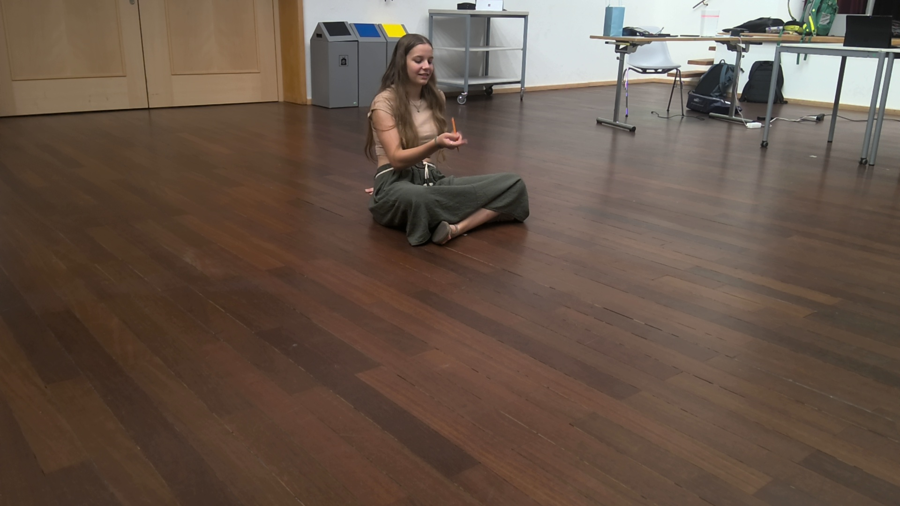

In [ ]:
# Show the first real camera for reference.
first_image = Image.open(CAMERA_PATHS[0]).convert("RGB")
print("First image size:", first_image.size)
display(first_image.resize((min(900, first_image.width), int(first_image.height * min(900, first_image.width) / first_image.width))))

## 7. Grounding DINO + SAM object helpers

In [ ]:
def inference_context():
    if DEVICE == "cuda":
        return torch.autocast("cuda", dtype=torch.float16)
    return nullcontext()


def expand_box(box, image_size, fraction=0.12):
    w_img, h_img = image_size
    x1, y1, x2, y2 = [float(v) for v in box]
    bw = max(1.0, x2 - x1)
    bh = max(1.0, y2 - y1)
    mx = bw * fraction
    my = bh * fraction
    return [
        max(0.0, x1 - mx),
        max(0.0, y1 - my),
        min(float(w_img - 1), x2 + mx),
        min(float(h_img - 1), y2 + my),
    ]


def restrict_mask_to_box(mask, box, expansion=0.18):
    """Stops SAM from swallowing a table/wall when the target is tiny."""
    h, w = mask.shape
    x1, y1, x2, y2 = expand_box(box, (w, h), expansion)
    x1, y1 = int(x1), int(y1)
    x2, y2 = int(np.ceil(x2)), int(np.ceil(y2))
    allowed = np.zeros_like(mask, dtype=np.uint8)
    allowed[max(0,y1):min(h,y2+1), max(0,x1):min(w,x2+1)] = 255
    return np.where(allowed > 0, mask, 0).astype(np.uint8)


def sam_refine_box(image, box):
    sam_box = expand_box(box, image.size, SAM_BOX_MARGIN)
    inputs = sam_processor(
        images=image,
        input_boxes=[[sam_box]],
        return_tensors="pt"
    ).to(DEVICE)

    with torch.inference_mode():
        with inference_context():
            outputs = sam_model(**inputs)

    masks = sam_processor.image_processor.post_process_masks(
        outputs.pred_masks.detach().cpu(),
        inputs["original_sizes"].detach().cpu(),
        inputs["reshaped_input_sizes"].detach().cpu()
    )[0][0]

    scores = outputs.iou_scores.detach().cpu()[0, 0]
    best_index = int(torch.argmax(scores).item())
    mask = np.where(np.squeeze(masks[best_index].numpy()) > 0, 255, 0).astype(np.uint8)

    # Critical for tiny objects such as a paper plane.
    mask = restrict_mask_to_box(mask, sam_box, OBJECT_MASK_BOX_EXPANSION)
    mask = cv2.GaussianBlur(mask, (3, 3), 0)
    return mask


def grounding_dino_candidates(image, prompt=TARGET_PROMPT):
    """Return plausible (score, box) candidates in original image coordinates."""
    inputs = object_processor(
        images=image,
        text=prompt,
        return_tensors="pt"
    ).to(DEVICE)

    with torch.inference_mode():
        outputs = object_detector(**inputs)

    target_sizes = torch.tensor([[image.height, image.width]])

    # Transformers has used both signatures across recent versions.
    try:
        processed = object_processor.post_process_grounded_object_detection(
            outputs,
            inputs.input_ids,
            box_threshold=OBJECT_BOX_THRESHOLD,
            text_threshold=OBJECT_TEXT_THRESHOLD,
            target_sizes=target_sizes,
        )[0]
    except TypeError:
        processed = object_processor.post_process_grounded_object_detection(
            outputs,
            input_ids=inputs.input_ids,
            threshold=OBJECT_BOX_THRESHOLD,
            text_threshold=OBJECT_TEXT_THRESHOLD,
            target_sizes=target_sizes,
        )[0]

    boxes = processed.get("boxes", torch.empty((0, 4)))
    scores = processed.get("scores", torch.empty((0,)))

    if torch.is_tensor(boxes):
        boxes = boxes.detach().cpu().numpy()
    else:
        boxes = np.asarray(boxes)

    if torch.is_tensor(scores):
        scores = scores.detach().cpu().numpy()
    else:
        scores = np.asarray(scores)

    image_area = float(image.width * image.height)
    candidates = []

    for score, box in zip(scores, boxes):
        x1, y1, x2, y2 = [float(v) for v in box]
        bw = max(0.0, x2 - x1)
        bh = max(0.0, y2 - y1)
        area_ratio = (bw * bh) / image_area

        if not (OBJECT_MIN_AREA_RATIO <= area_ratio <= OBJECT_MAX_AREA_RATIO):
            continue

        candidates.append((float(score), np.array([x1, y1, x2, y2], dtype=np.float32)))

    candidates.sort(key=lambda x: x[0], reverse=True)
    return candidates


def choose_object_candidate(candidates, person_box, image_size):
    """
    Prefer detector confidence, with a mild preference for candidates reasonably near
    the person. This is only a tie-breaker; the object may be separated in flight.
    """
    if not candidates:
        return None, None

    if person_box is None:
        return candidates[0]

    px1, py1, px2, py2 = [float(v) for v in person_box]
    pcx, pcy = (px1 + px2) / 2, (py1 + py2) / 2
    diag = math.hypot(*image_size)

    ranked = []
    for conf, box in candidates:
        x1, y1, x2, y2 = box
        cx, cy = (x1 + x2) / 2, (y1 + y2) / 2
        dist_norm = math.hypot(cx - pcx, cy - pcy) / max(diag, 1)
        combined = conf - 0.10 * dist_norm
        ranked.append((combined, conf, box))

    ranked.sort(key=lambda x: x[0], reverse=True)
    _, conf, box = ranked[0]
    return conf, box


def detect_target_object_mask(image, person_box=None):
    if not KEEP_EXTRA_OBJECT:
        return np.zeros((image.height, image.width), np.uint8), None, None

    candidates = grounding_dino_candidates(image, TARGET_PROMPT)
    confidence, box = choose_object_candidate(candidates, person_box, image.size)

    if box is None:
        return np.zeros((image.height, image.width), np.uint8), None, None

    mask = sam_refine_box(image, box)
    return mask, box, confidence

In [ ]:
from pathlib import Path
import shutil

# ==========================================================
# FOLDERS / PATHS
# ==========================================================

BASE_DIR = Path("/content/bullet_time")

INPUT_DIR = BASE_DIR / "input"
MASK_DIR = BASE_DIR / "masks"
OBJECT_MASK_DIR = BASE_DIR / "object_masks"
CUTOUT_DIR = BASE_DIR / "cutouts"
STABILIZED_DIR = BASE_DIR / "stabilized"
OUTPUT_DIR = BASE_DIR / "output"

# Create base/output folders
BASE_DIR.mkdir(parents=True, exist_ok=True)
INPUT_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("BASE_DIR:", BASE_DIR)
print("INPUT_DIR:", INPUT_DIR)
print("OUTPUT_DIR:", OUTPUT_DIR)

BASE_DIR: /content/bullet_time
INPUT_DIR: /content/bullet_time/input
OUTPUT_DIR: /content/bullet_time/output


## 8. Process all cameras

In [ ]:
print("Loading YOLO person segmenter...")
yolo_model = YOLO(YOLO_MODEL_NAME)

print("Loading Grounding DINO...")
object_processor = AutoProcessor.from_pretrained(
    GROUNDING_DINO_MODEL_ID
)

object_detector = AutoModelForZeroShotObjectDetection.from_pretrained(
    GROUNDING_DINO_MODEL_ID
).to(DEVICE)

object_detector.eval()

print("Loading SAM...")
sam_processor = SamProcessor.from_pretrained(
    SAM_MODEL_ID
)

sam_model = SamModel.from_pretrained(
    SAM_MODEL_ID
).to(DEVICE)

sam_model.eval()

print("All models ready.")

Loading YOLO person segmenter...
Loading Grounding DINO...
Loading SAM...
All models ready.


In [ ]:
# ==========================================================
# PROCESS ALL 29 REAL CAMERA IMAGES
# ==========================================================

for folder in [MASK_DIR, OBJECT_MASK_DIR, CUTOUT_DIR, STABILIZED_DIR]:
    shutil.rmtree(folder, ignore_errors=True)
    folder.mkdir(parents=True, exist_ok=True)

TARGET_SIZE = first_image.size

raw_images = []
human_masks = []
human_boxes = []
extra_masks = []
object_boxes = []
object_confidences = []
final_masks = []
cutouts = []
processed_camera_numbers = []
records = []

pipeline_start = time.time()

for idx, (camera_number, image_path) in enumerate(camera_items):
    start = time.time()
    print(f"[{idx + 1}/{len(camera_items)}] Camera {camera_number:02d}")

    record = {
        "camera": camera_number,
        "status": "SUCCESS",
        "object_found": False,
        "object_confidence": None,
        "seconds": None,
        "message": "",
    }

    try:
        raw = Image.open(image_path).convert("RGB")
        if raw.size != TARGET_SIZE:
            raw = raw.resize(TARGET_SIZE, Image.Resampling.LANCZOS)

        # 1) Person: fixed-class YOLO segmentation.
        human_mask, human_box = get_main_person_mask(raw)
        if human_mask is None:
            raise RuntimeError("No person detected.")

        # 2) Everyday object: independent open-vocabulary detection + SAM.
        try:
            extra_mask, object_box, object_confidence = detect_target_object_mask(
                raw,
                human_box,
            )
        except Exception as error:
            extra_mask = np.zeros_like(human_mask)
            object_box = None
            object_confidence = None
            record["message"] += f"Object detection failed: {type(error).__name__}: {error}. "

        if object_box is not None:
            record["object_found"] = True
            record["object_confidence"] = round(float(object_confidence), 4)
            print(f"    {TARGET_OBJECT}: found, confidence={object_confidence:.3f}")
        else:
            print(f"    {TARGET_OBJECT}: NOT FOUND")

        # 3) Union: preserve both person and target object.
        final_mask = np.maximum(human_mask, extra_mask)
        final_mask = cv2.GaussianBlur(final_mask, (3, 3), 0)

        rgba = np.array(raw.convert("RGBA"))
        rgba[:, :, 3] = final_mask
        cutout = Image.fromarray(rgba)

        raw_images.append(raw)
        human_masks.append(human_mask)
        human_boxes.append(human_box)
        extra_masks.append(extra_mask)
        object_boxes.append(object_box)
        object_confidences.append(object_confidence)
        final_masks.append(final_mask)
        cutouts.append(cutout)
        processed_camera_numbers.append(camera_number)

        # Save diagnostic masks immediately.
        Image.fromarray(human_mask).save(MASK_DIR / f"person_{camera_number:02d}.png")
        Image.fromarray(extra_mask).save(OBJECT_MASK_DIR / f"object_{camera_number:02d}.png")
        cutout.save(CUTOUT_DIR / f"camera_{camera_number:02d}.png")

    except Exception as error:
        record["status"] = "FAILED"
        record["message"] += f"{type(error).__name__}: {error}"
        print("    FAILED:", error)

    record["seconds"] = round(time.time() - start, 2)
    records.append(record)

records_df = pd.DataFrame(records)
display(records_df)

successful = int((records_df["status"] == "SUCCESS").sum())
found = int(records_df["object_found"].fillna(False).sum())
print(f"Successful camera frames: {successful}/{len(camera_items)}")
print(f"{TARGET_OBJECT} detected: {found}/{successful} successful frames")

if successful != len(camera_items):
    print("WARNING: one or more camera frames failed. Review the table before continuing.")

if KEEP_EXTRA_OBJECT and found < max(1, int(0.70 * successful)):
    print("WARNING: target-object recall is low. Try lowering OBJECT_BOX_THRESHOLD to 0.15 or expanding TARGET_PROMPT.")

[1/29] Camera 01
    pencil: found, confidence=0.339
[2/29] Camera 02
    pencil: found, confidence=0.382
[3/29] Camera 03
    pencil: found, confidence=0.298
[4/29] Camera 04
    pencil: found, confidence=0.410
[5/29] Camera 05
    pencil: found, confidence=0.351
[6/29] Camera 06
    pencil: found, confidence=0.358
[7/29] Camera 07
    pencil: found, confidence=0.413
[8/29] Camera 08
    pencil: found, confidence=0.360
[9/29] Camera 09
    pencil: found, confidence=0.294
[10/29] Camera 10
    pencil: found, confidence=0.302
[11/29] Camera 11
    pencil: found, confidence=0.380
[12/29] Camera 12
    pencil: found, confidence=0.347
[13/29] Camera 13
    pencil: found, confidence=0.361
[14/29] Camera 14
    pencil: found, confidence=0.372
[15/29] Camera 15
    pencil: found, confidence=0.353
[16/29] Camera 16
    pencil: found, confidence=0.371
[17/29] Camera 17
    pencil: found, confidence=0.259
[18/29] Camera 18
    pencil: found, confidence=0.342
[19/29] Camera 19
    pencil: found, 

,camera,status,object_found,object_confidence,seconds,message
0,1,SUCCESS,True,0.3385,1.35,
1,2,SUCCESS,True,0.3816,1.32,
2,3,SUCCESS,True,0.2976,1.41,
3,4,SUCCESS,True,0.4099,1.27,
4,5,SUCCESS,True,0.3509,1.35,
5,6,SUCCESS,True,0.3580,1.34,
6,7,SUCCESS,True,0.4127,1.38,
7,8,SUCCESS,True,0.3601,1.49,
8,9,SUCCESS,True,0.2936,1.25,
9,10,SUCCESS,True,0.3023,1.17,


Successful camera frames: 29/29
pencil detected: 29/29 successful frames


In [ ]:
# ==========================================================
# GEMINI GLOBAL 29-CAMERA ORDER
# Infer ONE complete anti-clockwise sequence
# ==========================================================

import json
from PIL import Image

# Always start from all 29 original camera files
numeric_camera_items = sorted(
    camera_items,
    key=lambda x: x[0]
)

contents = [
"""
You are given 29 photographs of exactly the same frozen moment,
taken simultaneously by cameras positioned around a person over
approximately a 180-degree arc.

Your job is to determine the PHYSICAL CAMERA ORDER around the subject.

IMPORTANT:
- Camera file numbers are arbitrary and may NOT represent physical order.
- Use the STATIC BACKGROUND perspective as the strongest cue.
- Also use changes in visible sides of the person's face/body,
  occlusions, perspective, and relative positions of background objects.
- Do NOT order by image similarity alone.
- The virtual camera must move continuously around the subject.
- It must NEVER reverse direction locally.
- Return the sequence in ANTI-CLOCKWISE direction.
- Every camera number 1 through 29 must occur EXACTLY ONCE.

Return ONLY valid JSON:

{
  "anticlockwise_order": [
    1, 2, 3
  ],
  "confidence": 0.0,
  "notes": "very short explanation"
}
"""
]

# Add every image with its camera identity.
for camera_number, image_path in numeric_camera_items:

    contents.append(
        f"CAMERA {camera_number}"
    )

    img = Image.open(
        image_path
    ).convert("RGB")

    # Enough visual detail for perspective reasoning,
    # while keeping the request manageable.
    img.thumbnail(
        (640, 640)
    )

    contents.append(img)


response = gemini_client.models.generate_content(
    model="gemini-3.6-flash",
    contents=contents
)

text = response.text.strip()

text = (
    text
    .replace("```json", "")
    .replace("```", "")
    .strip()
)

result = json.loads(text)

gemini_order = [
    int(x)
    for x in result[
        "anticlockwise_order"
    ]
]


# ----------------------------------------------------------
# STRICT VALIDATION
# ----------------------------------------------------------

expected = set(
    range(1, 30)
)

received = set(
    gemini_order
)

if (
    len(gemini_order) != 29
    or received != expected
):

    raise RuntimeError(
        "Gemini returned an invalid camera order:\n"
        + str(gemini_order)
    )


print()
print("Gemini anti-clockwise order:")
print(gemini_order)

print(
    "Confidence:",
    result.get(
        "confidence",
        "unknown"
    )
)

print(
    "Notes:",
    result.get(
        "notes",
        ""
    )
)


# ----------------------------------------------------------
# APPLY ORDER
# ----------------------------------------------------------

camera_lookup = {
    camera_number: path
    for camera_number, path
    in numeric_camera_items
}

camera_items = [
    (
        camera_number,
        camera_lookup[camera_number]
    )
    for camera_number
    in gemini_order
]

camera_numbers = list(
    gemini_order
)

print()
print("✓ New camera sequence applied:")
print(camera_numbers)


Gemini anti-clockwise order:
[4, 5, 7, 6, 14, 23, 26, 2, 1, 3, 27, 28, 21, 24, 9, 16, 8, 17, 10, 29, 11, 12, 18, 22, 13, 19, 15, 25, 20]
Confidence: 0.95
Notes: Determined anti-clockwise sequence around the subject from her right profile, through front view, to her left profile using static background shifts.

✓ New camera sequence applied:
[4, 5, 7, 6, 14, 23, 26, 2, 1, 3, 27, 28, 21, 24, 9, 16, 8, 17, 10, 29, 11, 12, 18, 22, 13, 19, 15, 25, 20]


In [ ]:
# ==========================================================
# GEMINI SECOND PASS:
# REMOVE CAMERAS THAT CAUSE LOCAL BACKWARD MOTION
#
# IMPORTANT:
# - Does NOT reorder the Gemini sequence.
# - It may ONLY remove problematic cameras.
# - Remaining cameras preserve the same anti-clockwise order.
# ==========================================================

import json
from PIL import Image


# Current order produced by the first Gemini pass
original_gemini_order = list(camera_numbers)

print("Input Gemini order:")
print(original_gemini_order)


# ----------------------------------------------------------
# Build second Gemini inspection request
# ----------------------------------------------------------

contents = [
"""
You are reviewing an already ordered bullet-time camera sequence.

The images are intended to move continuously ANTI-CLOCKWISE around
a frozen human subject over approximately 180 degrees.

The current sequence was already produced by another vision-model pass.

YOUR TASK IS NOT TO REORDER IT.

Instead, identify individual cameras that cause the apparent viewpoint
to temporarily move backwards or strongly break the otherwise smooth
anti-clockwise progression.

Use:
1. static background perspective,
2. visible side of the person's face/body,
3. shoulder/body rotation,
4. occlusion changes,
5. relative positions of background objects,
6. overall viewpoint progression.

RULES:

- Preserve the exact relative order of all retained cameras.
- You may ONLY REMOVE cameras.
- Remove a camera only when doing so makes the trajectory more
  consistently anti-clockwise.
- Do not remove a camera merely because its spacing is large.
- Do not remove cameras simply because two views look different.
- Prefer keeping as many cameras as possible.
- A short forward jump is better than a backwards step.
- Maximum recommended removals: 6 cameras.
- Never reverse subsequences.
- Never invent camera numbers.

Return ONLY valid JSON:

{
  "drop_cameras": [6, 14],
  "confidence": 0.0,
  "reason": "short explanation"
}
"""
]


# ----------------------------------------------------------
# Give Gemini every image IN THE CURRENT GEMINI ORDER
# ----------------------------------------------------------

camera_path_lookup = {
    number: path
    for number, path
    in camera_items
}


for position, camera_number in enumerate(
    original_gemini_order
):

    contents.append(
        f"SEQUENCE POSITION {position + 1} "
        f"- CAMERA {camera_number}"
    )

    img = Image.open(
        camera_path_lookup[
            camera_number
        ]
    ).convert("RGB")

    # Enough for perspective reasoning;
    # keeps request reasonably small.
    img.thumbnail(
        (640, 640)
    )

    contents.append(
        img
    )


# ----------------------------------------------------------
# Gemini critic pass
# ----------------------------------------------------------

response = gemini_client.models.generate_content(
    model="gemini-3.6-flash",
    contents=contents
)

text = response.text.strip()

text = (
    text
    .replace("```json", "")
    .replace("```", "")
    .strip()
)

critic_result = json.loads(
    text
)


drop_cameras = [
    int(x)
    for x
    in critic_result.get(
        "drop_cameras",
        []
    )
]


# ----------------------------------------------------------
# STRICT SAFETY CHECKS
# ----------------------------------------------------------

# Remove duplicates
drop_cameras = list(
    dict.fromkeys(
        drop_cameras
    )
)


# Gemini may only name cameras that actually exist
invalid = [
    x
    for x in drop_cameras
    if x not in original_gemini_order
]

if invalid:

    raise RuntimeError(
        "Gemini proposed invalid camera numbers: "
        + str(invalid)
    )


MAX_DROP_CAMERAS = 6

if len(drop_cameras) > MAX_DROP_CAMERAS:

    raise RuntimeError(
        f"Gemini wants to remove "
        f"{len(drop_cameras)} cameras. "
        f"Maximum allowed is {MAX_DROP_CAMERAS}. "
        "Review manually before proceeding."
    )


# ----------------------------------------------------------
# REMOVE ONLY — NEVER REORDER
# ----------------------------------------------------------

clean_camera_order = [
    camera_number
    for camera_number
    in original_gemini_order
    if camera_number not in drop_cameras
]


# Sanity check: enough cameras remain
if len(clean_camera_order) < 20:

    raise RuntimeError(
        "Too many cameras would be removed. "
        "Stopping for manual review."
    )


# ----------------------------------------------------------
# APPLY CLEANED ORDER
# ----------------------------------------------------------

camera_items = [
    (
        camera_number,
        camera_path_lookup[
            camera_number
        ]
    )
    for camera_number
    in clean_camera_order
]

camera_numbers = list(
    clean_camera_order
)


print()
print("=" * 70)

print(
    "Gemini reversal-cleanup confidence:",
    critic_result.get(
        "confidence",
        "unknown"
    )
)

print(
    "Reason:",
    critic_result.get(
        "reason",
        ""
    )
)

print()
print(
    "Removed cameras:",
    drop_cameras
)

print(
    "Cameras retained:",
    len(camera_numbers)
)

print()
print(
    "Final anti-clockwise sequence:"
)

print(
    camera_numbers
)

print("=" * 70)

Input Gemini order:
[4, 5, 7, 6, 14, 23, 26, 2, 1, 3, 27, 28, 21, 24, 9, 16, 8, 17, 10, 29, 11, 12, 18, 22, 13, 19, 15, 25, 20]

Gemini reversal-cleanup confidence: 0.95
Reason: Cameras 10 and 25 jump too far ahead in the anti-clockwise rotation relative to their adjacent frames, causing brief backward viewpoint movements.

Removed cameras: [10, 25]
Cameras retained: 27

Final anti-clockwise sequence:
[4, 5, 7, 6, 14, 23, 26, 2, 1, 3, 27, 28, 21, 24, 9, 16, 8, 17, 29, 11, 12, 18, 22, 13, 19, 15, 20]


In [ ]:
# ==========================================================
# REFERENCE-POINT MONOTONIC CLEANUP
#
# Assumes camera_items is already in Gemini anti-clockwise order.
#
# Uses SIFT + RANSAC background correspondences.
# It NEVER reorders cameras.
# It can ONLY remove a camera that creates a strong
# local backwards transition.
# ==========================================================

import cv2
import numpy as np
from PIL import Image


# ----------------------------------------------------------
# SETTINGS
# ----------------------------------------------------------

REF_WIDTH = 900

REF_SIFT_FEATURES = 5000
REF_LOWE_RATIO = 0.80

REF_MIN_MATCHES = 12
REF_MIN_INLIERS = 15

# Strong evidence required before dropping anything.
REF_MIN_AGREEMENT = 0.80

# Ignore near-zero motion
REF_MIN_MOTION_PX = 2.0

# Don't remove too many cameras automatically.
MAX_REFERENCE_DROPS = 6


# ----------------------------------------------------------
# FEATURE EXTRACTION
# ----------------------------------------------------------

ref_sift = cv2.SIFT_create(
    nfeatures=REF_SIFT_FEATURES
)

ref_matcher = cv2.BFMatcher(
    cv2.NORM_L2
)


def ref_extract(path):

    img = Image.open(
        path
    ).convert("RGB")

    rgb = np.array(img)

    h0, w0 = rgb.shape[:2]

    scale = min(
        1.0,
        REF_WIDTH / float(w0)
    )

    if scale < 1.0:

        rgb = cv2.resize(
            rgb,
            (
                int(round(w0 * scale)),
                int(round(h0 * scale))
            ),
            interpolation=cv2.INTER_AREA
        )

    gray = cv2.cvtColor(
        rgb,
        cv2.COLOR_RGB2GRAY
    )

    h, w = gray.shape

    # Keep most of the background.
    # Only suppress central subject-heavy region.
    mask = np.full(
        (h, w),
        255,
        dtype=np.uint8
    )

    cv2.rectangle(
        mask,
        (
            int(0.34 * w),
            int(0.10 * h)
        ),
        (
            int(0.66 * w),
            int(0.92 * h)
        ),
        0,
        -1
    )

    kp, des = ref_sift.detectAndCompute(
        gray,
        mask
    )

    return kp, des


# ----------------------------------------------------------
# MEASURE BACKGROUND MOTION BETWEEN TWO CAMERAS
# ----------------------------------------------------------

def ref_pair_motion(
    feature_a,
    feature_b
):

    kpA, desA = feature_a
    kpB, desB = feature_b

    if (
        desA is None
        or desB is None
        or len(desA) < REF_MIN_MATCHES
        or len(desB) < REF_MIN_MATCHES
    ):
        return None

    matches = ref_matcher.knnMatch(
        desA,
        desB,
        k=2
    )

    good = []

    for pair in matches:

        if len(pair) != 2:
            continue

        m, n = pair

        if (
            m.distance
            < REF_LOWE_RATIO
            * n.distance
        ):
            good.append(m)

    if len(good) < REF_MIN_MATCHES:
        return None

    ptsA = np.float32([
        kpA[m.queryIdx].pt
        for m in good
    ])

    ptsB = np.float32([
        kpB[m.trainIdx].pt
        for m in good
    ])

    H, inliers = cv2.findHomography(
        ptsA,
        ptsB,
        cv2.RANSAC,
        5.0
    )

    if (
        H is None
        or inliers is None
    ):
        return None

    keep = (
        inliers.ravel()
        > 0
    )

    A = ptsA[keep]
    B = ptsB[keep]

    if len(A) < REF_MIN_INLIERS:
        return None

    dx = (
        B[:, 0]
        - A[:, 0]
    )

    median_dx = float(
        np.median(dx)
    )

    if abs(median_dx) < REF_MIN_MOTION_PX:
        agreement = 0.0
    else:

        sign = np.sign(
            median_dx
        )

        agreement = float(
            np.mean(
                np.sign(dx)
                == sign
            )
        )

    return {
        "dx":
            median_dx,

        "matches":
            len(good),

        "inliers":
            len(A),

        "agreement":
            agreement,
    }


# ----------------------------------------------------------
# CURRENT GEMINI ORDER
# ----------------------------------------------------------

working_items = list(
    camera_items
)

print(
    "Starting reference-point cleanup:"
)

print([
    n
    for n, _
    in working_items
])


# ----------------------------------------------------------
# FEATURE CACHE
# ----------------------------------------------------------

feature_cache = {}


def get_ref_feature(
    camera_number,
    path
):

    if camera_number not in feature_cache:

        feature_cache[
            camera_number
        ] = ref_extract(
            path
        )

    return feature_cache[
        camera_number
    ]


def measure_items_pair(
    item_a,
    item_b
):

    na, pa = item_a
    nb, pb = item_b

    return ref_pair_motion(
        get_ref_feature(
            na,
            pa
        ),
        get_ref_feature(
            nb,
            pb
        )
    )


# ----------------------------------------------------------
# ESTABLISH EXPECTED DIRECTION
# ----------------------------------------------------------

initial_results = []

for i in range(
    len(working_items) - 1
):

    r = measure_items_pair(
        working_items[i],
        working_items[i + 1]
    )

    if (
        r is not None
        and r["inliers"] >= REF_MIN_INLIERS
        and r["agreement"] >= REF_MIN_AGREEMENT
        and abs(r["dx"]) >= REF_MIN_MOTION_PX
    ):

        initial_results.append(
            r["dx"]
        )


if len(initial_results) < 3:

    raise RuntimeError(
        "Not enough reliable reference-point "
        "transitions to determine direction."
    )


# Majority vote by sign.
sign_votes = np.sign(
    initial_results
)

expected_sign = int(
    np.sign(
        np.sum(
            sign_votes
        )
    )
)


if expected_sign == 0:

    raise RuntimeError(
        "Reference-point direction is ambiguous."
    )


print(
    "Expected anti-clockwise motion sign:",
    expected_sign
)


# ----------------------------------------------------------
# LOCAL QUALITY SCORE
# ----------------------------------------------------------

def local_reference_score(
    items,
    center
):

    start = max(
        0,
        center - 2
    )

    end = min(
        len(items) - 1,
        center + 2
    )

    score = 0.0

    for i in range(
        start,
        end
    ):

        r = measure_items_pair(
            items[i],
            items[i + 1]
        )

        if r is None:

            # Uncertain is mildly bad,
            # but not as bad as proven reverse motion.
            score += 2.0
            continue

        dx = r["dx"]

        reliable = (
            r["inliers"] >= REF_MIN_INLIERS
            and
            r["agreement"] >= REF_MIN_AGREEMENT
            and
            abs(dx) >= REF_MIN_MOTION_PX
        )

        if reliable:

            if np.sign(dx) != expected_sign:

                # Huge penalty for reverse motion
                score += 20.0

            else:

                # Forward transition is good.
                score -= 1.0

        # Penalize enormous jumps a little
        score += min(
            abs(dx) / 300.0,
            2.0
        )

    return score


# ----------------------------------------------------------
# REMOVE ONLY CAMERAS THAT CAUSE STRONG REVERSALS
# ----------------------------------------------------------

removed_by_reference = []

for cleanup_round in range(
    MAX_REFERENCE_DROPS
):

    bad_index = None
    bad_result = None

    for i in range(
        len(working_items) - 1
    ):

        r = measure_items_pair(
            working_items[i],
            working_items[i + 1]
        )

        if r is None:
            continue

        reliable_reverse = (
            r["inliers"] >= REF_MIN_INLIERS
            and
            r["agreement"] >= REF_MIN_AGREEMENT
            and
            abs(r["dx"]) >= REF_MIN_MOTION_PX
            and
            np.sign(r["dx"])
            != expected_sign
        )

        if reliable_reverse:

            bad_index = i
            bad_result = r
            break


    if bad_index is None:

        print(
            "No high-confidence backwards "
            "transitions remain."
        )

        break


    a_number = (
        working_items[
            bad_index
        ][0]
    )

    b_number = (
        working_items[
            bad_index + 1
        ][0]
    )


    print()
    print(
        f"Backwards transition found: "
        f"{a_number} -> {b_number}"
    )

    print(
        "dx:",
        round(
            bad_result["dx"],
            2
        ),
        "inliers:",
        bad_result["inliers"],
        "agreement:",
        round(
            bad_result["agreement"],
            3
        )
    )


    # ------------------------------------------------------
    # OPTION A:
    # remove the first camera
    # ------------------------------------------------------

    candidate_drop_a = (
        working_items[:bad_index]
        + working_items[
            bad_index + 1:
        ]
    )

    score_a = local_reference_score(
        candidate_drop_a,
        max(
            0,
            bad_index - 1
        )
    )


    # ------------------------------------------------------
    # OPTION B:
    # remove the second camera
    # ------------------------------------------------------

    candidate_drop_b = (
        working_items[
            :bad_index + 1
        ]
        + working_items[
            bad_index + 2:
        ]
    )

    score_b = local_reference_score(
        candidate_drop_b,
        bad_index
    )


    print(
        f"  drop {a_number}: "
        f"score={score_a:.3f}"
    )

    print(
        f"  drop {b_number}: "
        f"score={score_b:.3f}"
    )


    if score_a < score_b:

        dropped = a_number

        working_items = (
            candidate_drop_a
        )

    else:

        dropped = b_number

        working_items = (
            candidate_drop_b
        )


    removed_by_reference.append(
        dropped
    )


    print(
        "  -> removed camera",
        dropped
    )


# ----------------------------------------------------------
# APPLY CLEANED ORDER
# ----------------------------------------------------------

camera_items = list(
    working_items
)

camera_numbers = [
    n
    for n, _
    in camera_items
]


print()
print("=" * 72)

print(
    "Reference-point removals:",
    removed_by_reference
)

print(
    "Final cameras retained:",
    len(camera_numbers)
)

print(
    "Final order:"
)

print(
    camera_numbers
)

print("=" * 72)

Starting reference-point cleanup:
[4, 5, 7, 6, 14, 23, 26, 2, 1, 3, 27, 28, 21, 24, 9, 16, 8, 17, 29, 11, 12, 18, 22, 13, 19, 15, 20]
Expected anti-clockwise motion sign: 1

Backwards transition found: 27 -> 28
dx: -39.62 inliers: 47 agreement: 0.872
  drop 27: score=-3.086
  drop 28: score=-2.417
  -> removed camera 27
No high-confidence backwards transitions remain.

Reference-point removals: [27]
Final cameras retained: 26
Final order:
[4, 5, 7, 6, 14, 23, 26, 2, 1, 3, 28, 21, 24, 9, 16, 8, 17, 29, 11, 12, 18, 22, 13, 19, 15, 20]


In [ ]:
# ==========================================================
# QUICK PREVIEW OF REPAIRED CAMERA ORDER
# H.264 VERSION FOR COLAB
# ==========================================================

import shutil
import subprocess
import numpy as np
from pathlib import Path
from PIL import Image
from IPython.display import Video, display

PREVIEW_DIR = Path(
    "/content/repaired_preview_frames"
)

PREVIEW_PATH = Path(
    "/content/repaired_camera_order_preview.mp4"
)

PREVIEW_FPS = 5

shutil.rmtree(
    PREVIEW_DIR,
    ignore_errors=True
)

PREVIEW_DIR.mkdir(
    parents=True,
    exist_ok=True
)

# ----------------------------------------------------------
# Save repaired-order RGB frames as JPGs
# ----------------------------------------------------------

for i, (
    camera_number,
    image_path
) in enumerate(camera_items):

    img = Image.open(
        image_path
    ).convert("RGB")

    # Resize only for preview speed
    img.thumbnail(
        (900, 900)
    )

    img.save(
        PREVIEW_DIR / f"frame_{i:03d}.jpg",
        quality=90
    )

# ----------------------------------------------------------
# Encode with H.264
# ----------------------------------------------------------

subprocess.run(
    [
        "ffmpeg",
        "-y",
        "-loglevel",
        "error",
        "-framerate",
        str(PREVIEW_FPS),
        "-i",
        str(
            PREVIEW_DIR
            / "frame_%03d.jpg"
        ),
        "-c:v",
        "libx264",
        "-pix_fmt",
        "yuv420p",
        "-movflags",
        "+faststart",
        str(PREVIEW_PATH)
    ],
    check=True
)

print(
    "Preview order:",
    camera_numbers
)

print(
    "Preview saved:",
    PREVIEW_PATH
)

display(
    Video(
        str(PREVIEW_PATH),
        embed=True,
        width=900
    )
)

Preview order: [4, 5, 7, 6, 14, 23, 26, 2, 1, 3, 28, 21, 24, 9, 16, 8, 17, 29, 11, 12, 18, 22, 13, 19, 15, 20]
Preview saved: /content/repaired_camera_order_preview.mp4


In [ ]:
# ==========================================================
# REPAIR SUSPICIOUS PERSON MASKS
# ==========================================================

def person_geometry(
    mask
):

    ys, xs = np.where(
        mask > 40
    )


    if len(xs) == 0:

        return None


    x1 = int(
        xs.min()
    )

    x2 = int(
        xs.max()
    )

    y1 = int(
        ys.min()
    )

    y2 = int(
        ys.max()
    )


    return {

        "cx":
            0.5
            * (
                x1
                + x2
            ),

        "cy":
            0.5
            * (
                y1
                + y2
            ),

        "height":
            y2
            - y1
            + 1,

        "width":
            x2
            - x1
            + 1
    }


human_geometries = [

    person_geometry(
        mask
    )

    for mask
    in human_masks
]


bad_indices = []


for i in range(
    1,
    len(
        human_geometries
    ) - 1
):

    previous = (
        human_geometries[
            i - 1
        ]
    )

    current = (
        human_geometries[
            i
        ]
    )

    following = (
        human_geometries[
            i + 1
        ]
    )


    if (
        previous is None
        or current is None
        or following is None
    ):

        bad_indices.append(
            i
        )

        continue


    neighbour_height = (
        0.5
        * (
            previous[
                "height"
            ]
            +
            following[
                "height"
            ]
        )
    )


    height_ratio = (
        current[
            "height"
        ]
        /
        max(
            neighbour_height,
            1
        )
    )


    expected_cx = (
        0.5
        * (
            previous[
                "cx"
            ]
            +
            following[
                "cx"
            ]
        )
    )


    expected_cy = (
        0.5
        * (
            previous[
                "cy"
            ]
            +
            following[
                "cy"
            ]
        )
    )


    center_error = math.hypot(

        current[
            "cx"
        ]
        - expected_cx,

        current[
            "cy"
        ]
        - expected_cy
    )


    if (

        height_ratio
        < PERSON_HEIGHT_RATIO_MIN

        or

        height_ratio
        > PERSON_HEIGHT_RATIO_MAX

        or

        center_error
        > PERSON_CENTER_ERROR_MAX
    ):

        bad_indices.append(
            i
        )


print(
    "Suspicious cameras:",
    [
        processed_camera_numbers[i]
        for i in bad_indices
    ]
)

Suspicious cameras: [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28]


## 9. Stabilize from the person only

In [ ]:
# ==========================================================
# IMPROVED 180-DEG CAMERA ORDERING
# Spectral seriation + local path refinement
# ==========================================================

import numpy as np
import cv2
from PIL import Image


# ----------------------------------------------------------
# SETTINGS
# ----------------------------------------------------------

ORDER_SIZE = 160

# More weight on person appearance than the plane.
ORDER_ALPHA_WEIGHT = 0.40
ORDER_RGB_WEIGHT = 0.60

# Number of nearest visual neighbors used to build the graph.
ORDER_K_NEIGHBORS = 5


# ----------------------------------------------------------
# FEATURE EXTRACTION
# ----------------------------------------------------------

def ordering_feature(frame):
    """
    Extract a normalized foreground-centered visual feature.
    The paper plane contributes, but the person dominates.
    """

    rgba = np.array(frame.convert("RGBA"))

    rgb = rgba[:, :, :3]
    alpha = rgba[:, :, 3]

    ys, xs = np.where(alpha > 25)

    if len(xs) == 0:
        crop_rgb = rgb
        crop_alpha = alpha

    else:
        x1, x2 = xs.min(), xs.max()
        y1, y2 = ys.min(), ys.max()

        # Avoid letting the paper plane make the crop enormous.
        # Keep a generous person-centered crop.
        cx = (x1 + x2) / 2
        cy = (y1 + y2) / 2

        bw = x2 - x1 + 1
        bh = y2 - y1 + 1

        crop_w = int(max(bw, bh * 1.25))
        crop_h = int(max(bh, bw * 0.80))

        xa = int(max(0, cx - crop_w / 2))
        xb = int(min(rgb.shape[1], cx + crop_w / 2))

        ya = int(max(0, cy - crop_h / 2))
        yb = int(min(rgb.shape[0], cy + crop_h / 2))

        crop_rgb = rgb[ya:yb, xa:xb]
        crop_alpha = alpha[ya:yb, xa:xb]

    crop_rgb = cv2.resize(
        crop_rgb,
        (ORDER_SIZE, ORDER_SIZE),
        interpolation=cv2.INTER_AREA
    )

    crop_alpha = cv2.resize(
        crop_alpha,
        (ORDER_SIZE, ORDER_SIZE),
        interpolation=cv2.INTER_AREA
    )

    mask = crop_alpha.astype(np.float32) / 255.0

    rgb_f = crop_rgb.astype(np.float32) / 255.0
    rgb_f *= mask[..., None]

    # Slight blur suppresses segmentation-edge noise.
    rgb_f = cv2.GaussianBlur(
        rgb_f,
        (5, 5),
        0
    )

    mask = cv2.GaussianBlur(
        mask,
        (5, 5),
        0
    )

    alpha_vec = mask.flatten()
    rgb_vec = rgb_f.flatten()

    alpha_vec /= (
        np.linalg.norm(alpha_vec) + 1e-8
    )

    rgb_vec /= (
        np.linalg.norm(rgb_vec) + 1e-8
    )

    return alpha_vec, rgb_vec


# Initialize stabilized_cutouts with cutouts to fix the NameError
# In a complete pipeline, stabilized_cutouts would come from a stabilization step.
stabilized_cutouts = cutouts

features = [
    ordering_feature(frame)
    for frame in stabilized_cutouts
]


# ----------------------------------------------------------
# PAIRWISE DISTANCE MATRIX
# ----------------------------------------------------------

N = len(features)

D = np.zeros(
    (N, N),
    dtype=np.float64
)

for i in range(N):

    ai, ri = features[i]

    for j in range(i + 1, N):

        aj, rj = features[j]

        da = 1.0 - np.clip(
            np.dot(ai, aj),
            -1.0,
            1.0
        )

        dr = 1.0 - np.clip(
            np.dot(ri, rj),
            -1.0,
            1.0
        )

        d = (
            ORDER_ALPHA_WEIGHT * da
            + ORDER_RGB_WEIGHT * dr
        )

        D[i, j] = d
        D[j, i] = d


# ----------------------------------------------------------
# BUILD KNN SIMILARITY GRAPH
# ----------------------------------------------------------

# Characteristic distance.
nonzero = D[D > 0]

sigma = np.median(nonzero)

if sigma <= 0:
    sigma = 1.0


W = np.zeros(
    (N, N),
    dtype=np.float64
)


for i in range(N):

    nearest = np.argsort(D[i])[
        1:ORDER_K_NEIGHBORS + 1
    ]

    for j in nearest:

        similarity = np.exp(
            -(D[i, j] ** 2)
            / (2 * sigma ** 2)
        )

        W[i, j] = max(
            W[i, j],
            similarity
        )

        W[j, i] = max(
            W[j, i],
            similarity
        )


# ----------------------------------------------------------
# SPECTRAL SERIATION
# ----------------------------------------------------------

degree = np.sum(
    W,
    axis=1
)

L = np.diag(degree) - W


eigenvalues, eigenvectors = np.linalg.eigh(L)

# Eigenvector 0 corresponds to constant solution.
# Eigenvector 1 is the Fiedler vector and gives a 1D ordering.
fiedler = eigenvectors[:, 1]


spectral_order = list(
    np.argsort(fiedler)
)


# ----------------------------------------------------------
# OPEN-PATH COST
# ----------------------------------------------------------

def path_cost(order):

    return sum(
        D[
            order[i],
            order[i + 1]
        ]
        for i in range(len(order) - 1)
    )


# ----------------------------------------------------------
# 2-OPT FOR AN OPEN PATH
# ----------------------------------------------------------

def two_opt_open(order, max_rounds=100):

    best = order[:]
    best_cost = path_cost(best)

    n = len(best)

    for _ in range(max_rounds):

        improved = False

        for i in range(1, n - 2):

            for j in range(i + 1, n):

                candidate = (
                    best[:i]
                    + best[i:j][::-1]
                    + best[j:]
                )

                c = path_cost(candidate)

                if c + 1e-10 < best_cost:

                    best = candidate
                    best_cost = c
                    improved = True

        if not improved:
            break

    return best


order = two_opt_open(
    spectral_order
)


# ----------------------------------------------------------
# OPTIONAL ORIENTATION SELECTION
# ----------------------------------------------------------

# The correct path can appear forwards or backwards.
# Both are equally valid mathematically.
# Choose one deterministic orientation by camera number.

forward = order
reverse = order[::-1]

forward_numbers = [
    processed_camera_numbers[i]
    for i in forward
]

reverse_numbers = [
    processed_camera_numbers[i]
    for i in reverse
]

# This is only to make the result deterministic.
# It does NOT assume numeric camera order.
if forward_numbers[0] <= reverse_numbers[0]:
    order = forward
else:
    order = reverse


# ----------------------------------------------------------
# APPLY ORDER
# ----------------------------------------------------------

master_frames = [
    stabilized_cutouts[i]
    for i in order
]

ordered_camera_numbers = [
    processed_camera_numbers[i]
    for i in order
]


print("Improved 180-degree camera order:")
print(ordered_camera_numbers)

print()
print("Path cost:", round(path_cost(order), 5))

print()
print("Frames:", len(master_frames))

Improved 180-degree camera order:
[4, 5, 14, 6, 7, 23, 26, 2, 1, 3, 28, 27, 21, 24, 9, 16, 8, 17, 29, 10, 11, 12, 18, 22, 13, 19, 15, 20, 25]

Path cost: 1.92258

Frames: 29


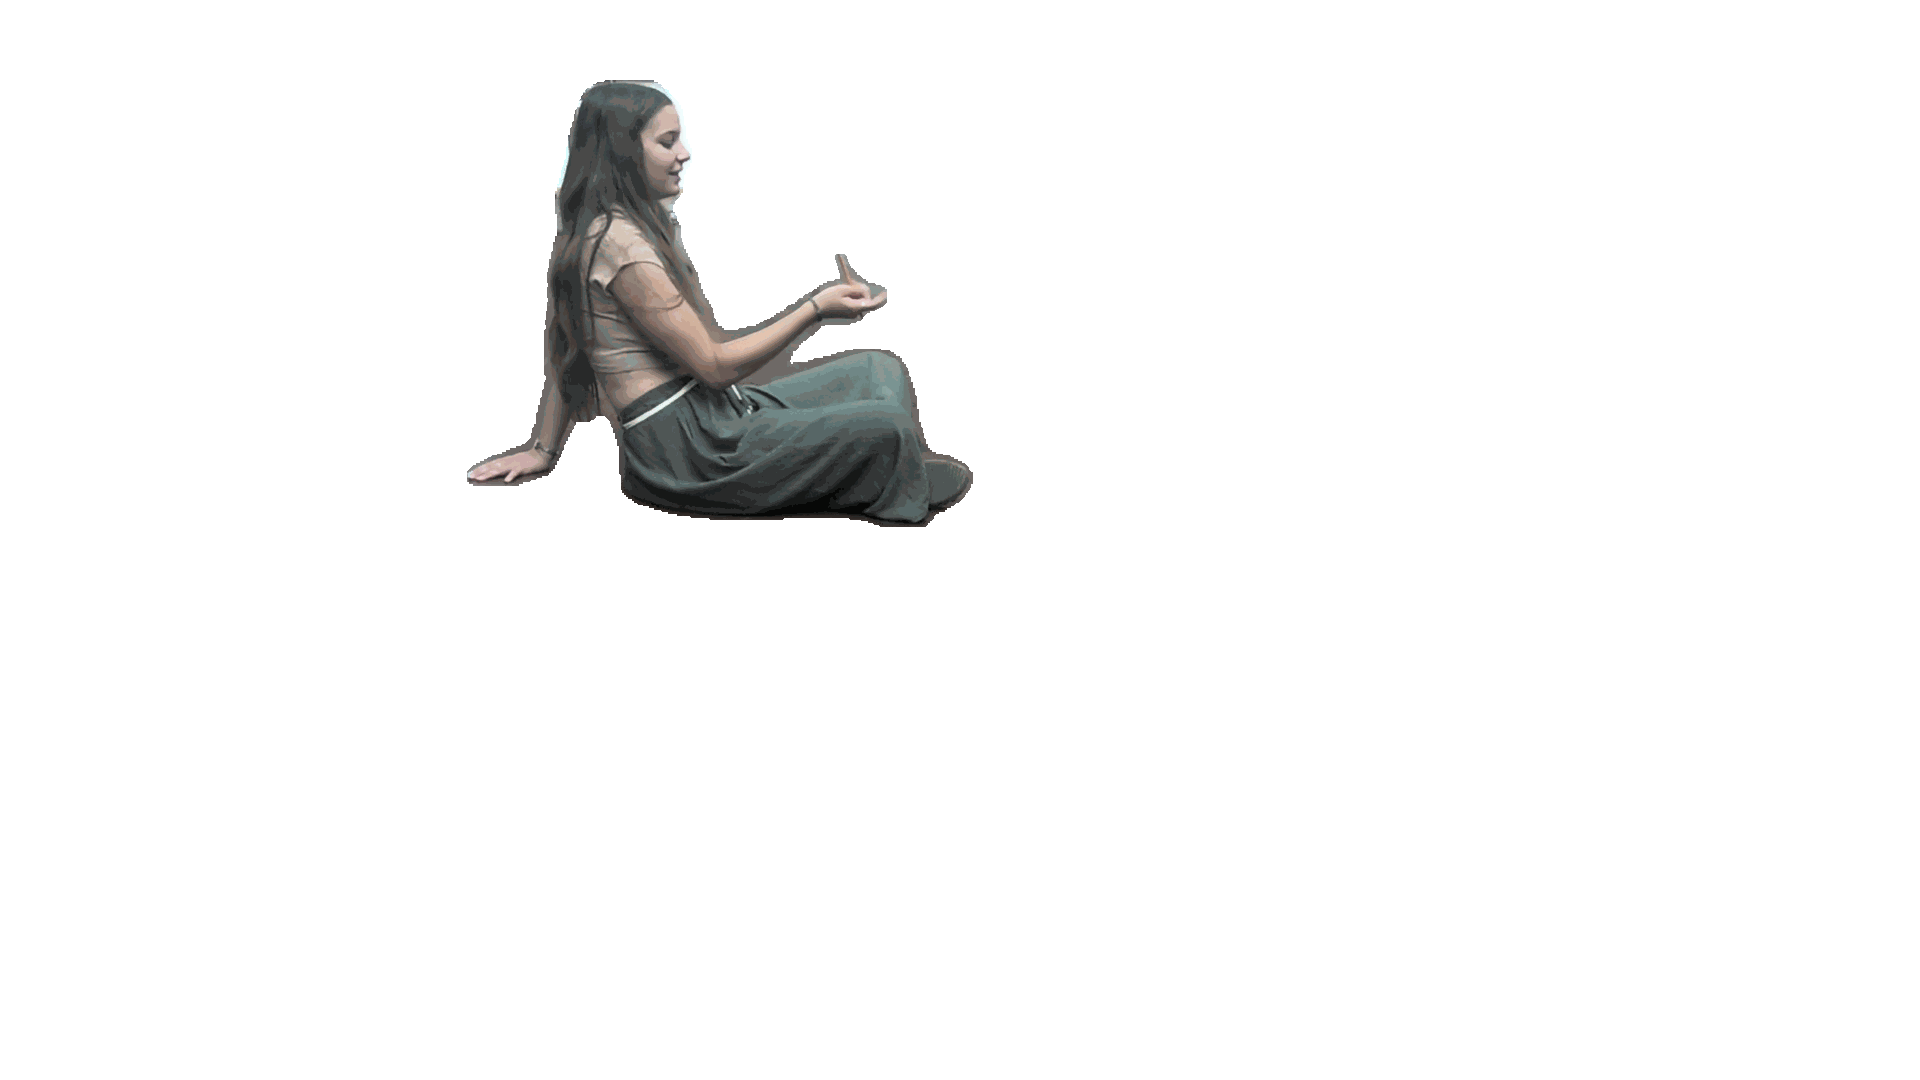

In [ ]:
# ==========================================================
# PREVIEW REAL SEGMENTED CAMERA SEQUENCE
# ==========================================================

from IPython.display import display
from PIL import Image

PREVIEW_MS = 180

preview_frames = [
    f.convert("RGBA")
    for f in master_frames
]

preview_frames[0].save(
    "/content/camera_preview.gif",
    save_all=True,
    append_images=preview_frames[1:],
    duration=PREVIEW_MS,
    loop=0,
    disposal=2
)

display(
    Image.open("/content/camera_preview.gif")
)

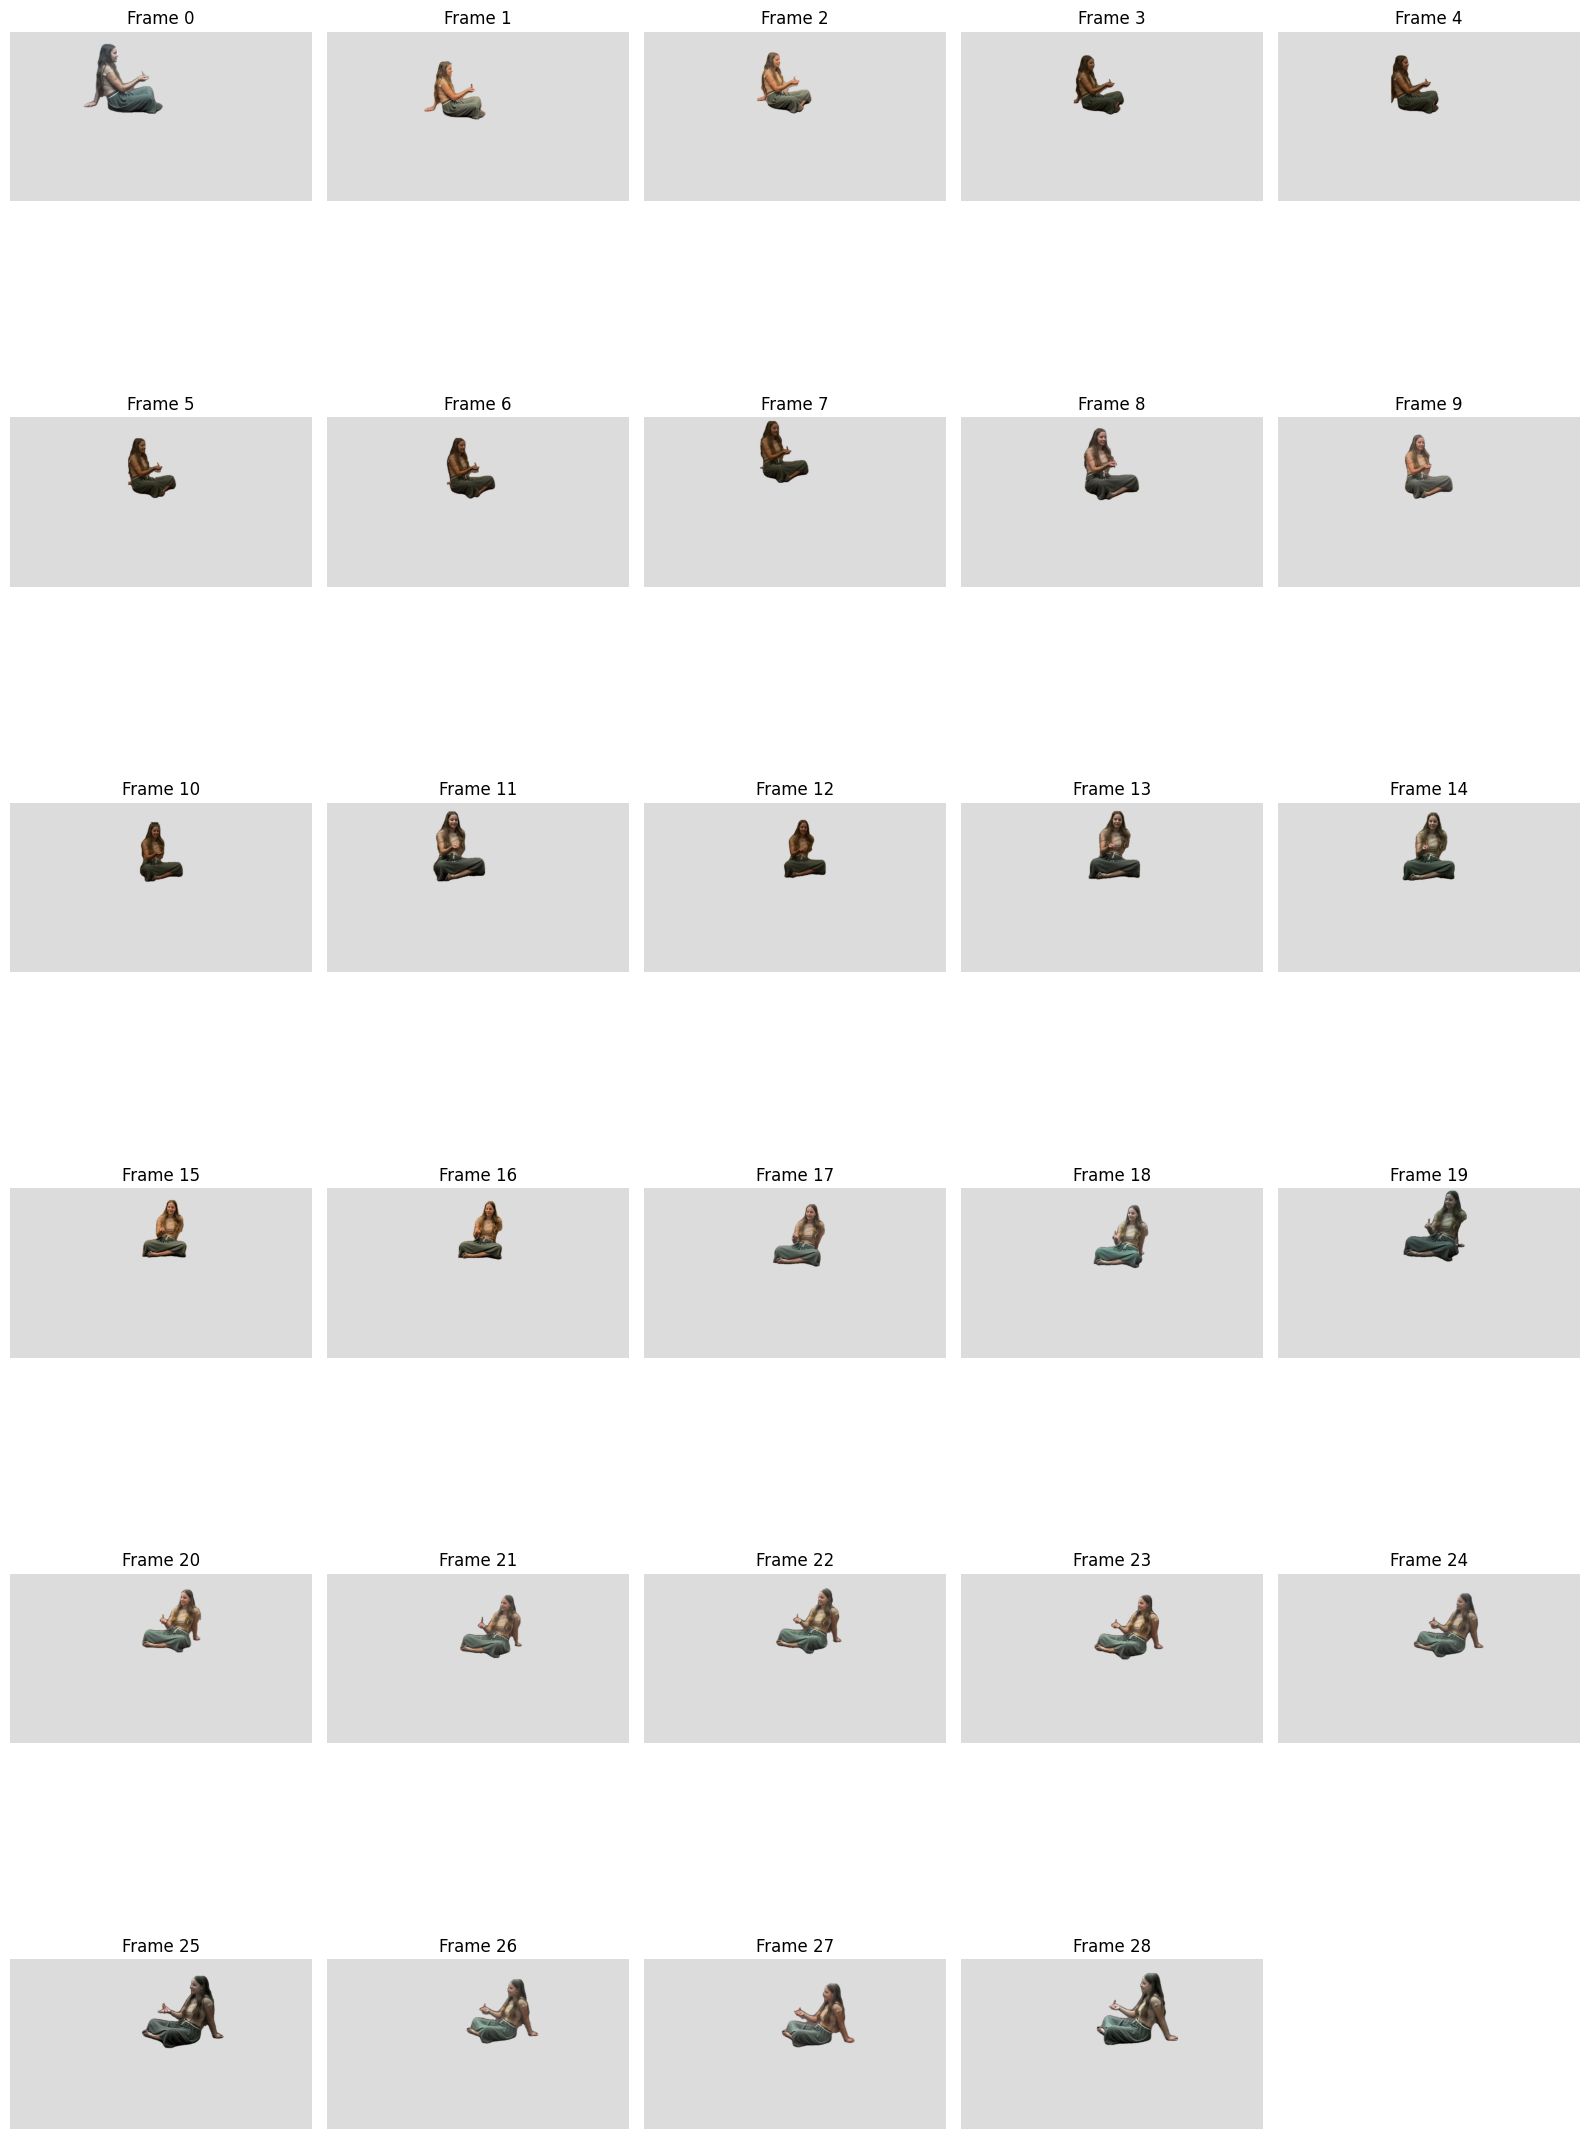

In [ ]:
# ==========================================================
# CAMERA CONTACT SHEET
# ==========================================================

import matplotlib.pyplot as plt
import math

cols = 5
rows = math.ceil(len(master_frames) / cols)

plt.figure(figsize=(16, rows * 4))

for i, frame in enumerate(master_frames):

    plt.subplot(rows, cols, i + 1)

    # checker/white background makes unwanted mask pieces visible
    rgba = np.array(frame.convert("RGBA"))

    background = np.ones(
        (rgba.shape[0], rgba.shape[1], 3),
        dtype=np.uint8
    ) * 220

    a = rgba[:, :, 3:4] / 255.0

    composite = (
        rgba[:, :, :3] * a
        + background * (1-a)
    ).astype(np.uint8)

    plt.imshow(composite)

    plt.title(
        f"Frame {i}"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()


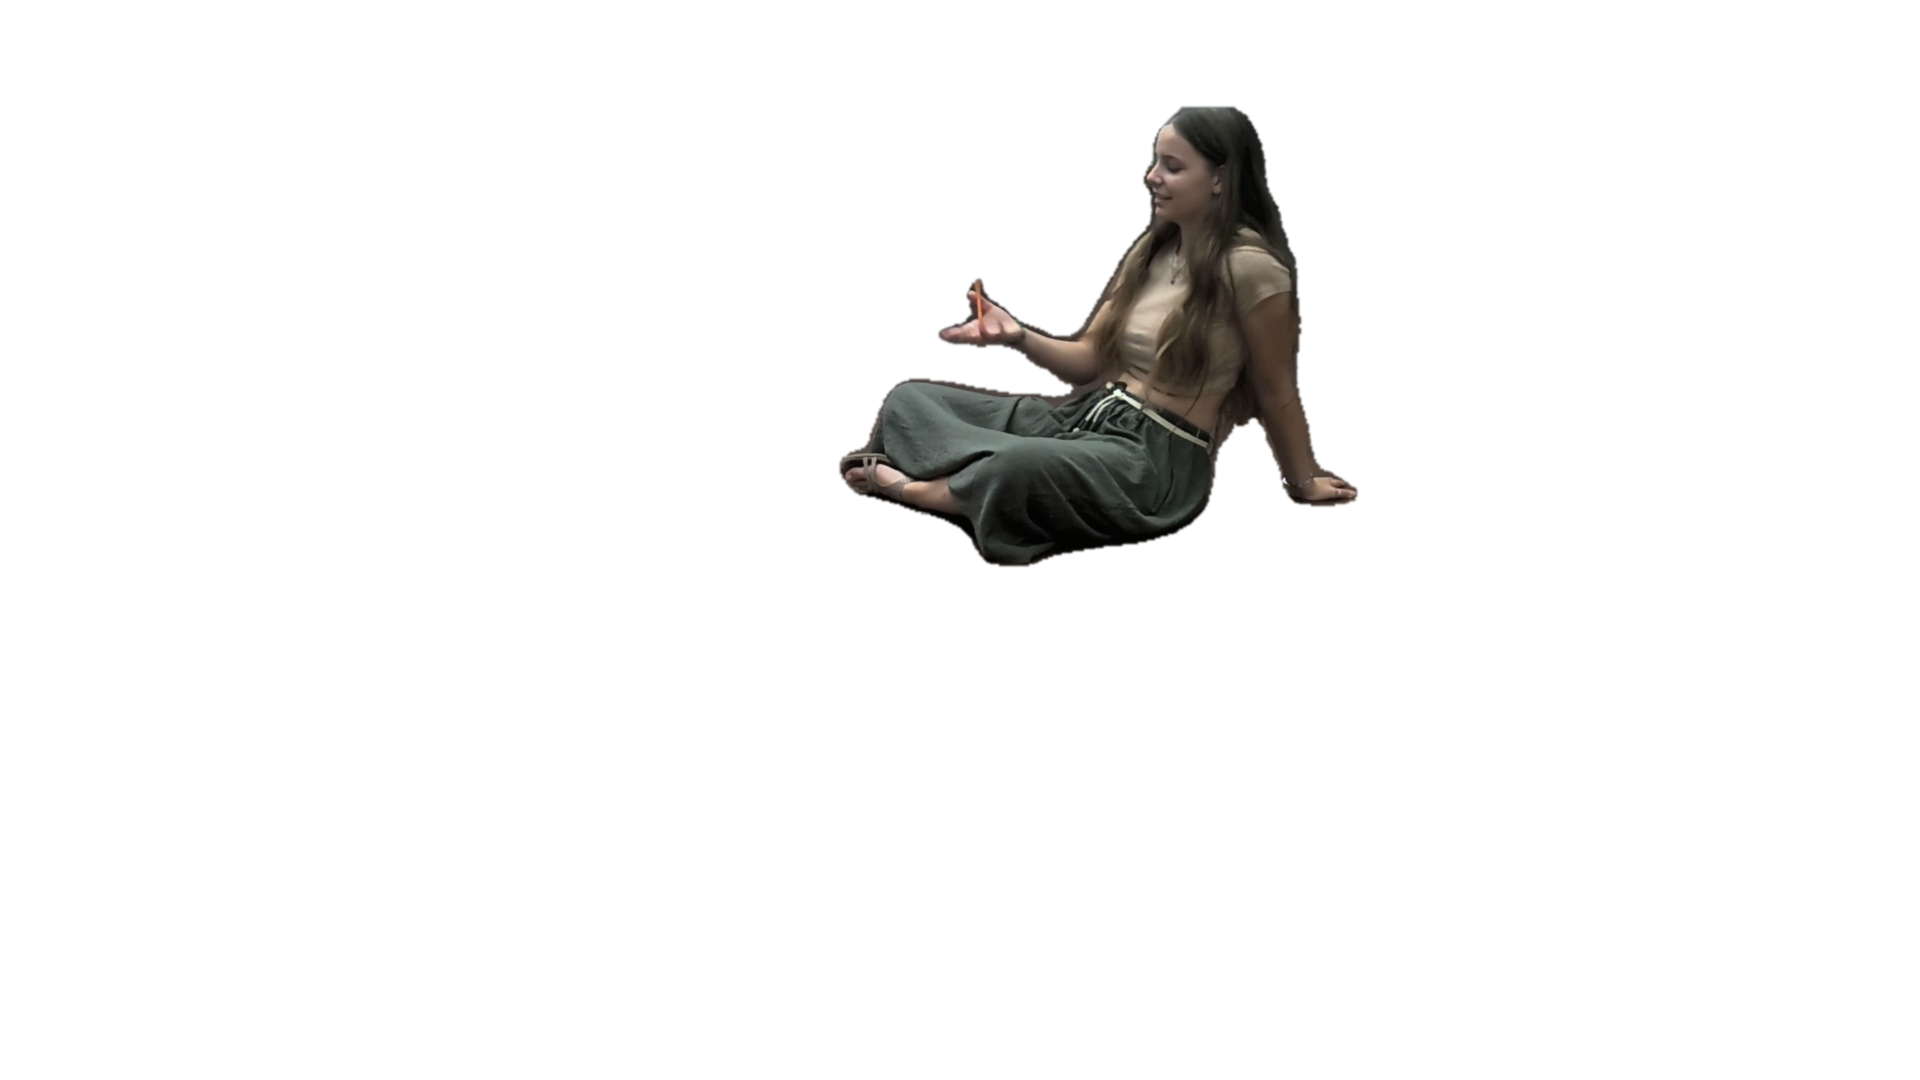

In [ ]:
# ==========================================================
# COLAB INTERACTIVE MASK ERASER
# Paint directly on the image
# ==========================================================

from google.colab import output
from IPython.display import display, HTML
from PIL import Image
import numpy as np
import base64
import io

EDIT_FRAME = 25
ERASER_RADIUS = 30


# ----------------------------------------------------------
# Prepare image
# ----------------------------------------------------------

working_frame = np.array(
    master_frames[EDIT_FRAME].convert("RGBA")
).copy()

img = Image.fromarray(working_frame)

buffer = io.BytesIO()
img.save(buffer, format="PNG")

img64 = base64.b64encode(
    buffer.getvalue()
).decode()


# ----------------------------------------------------------
# Python callback
# ----------------------------------------------------------

def erase_points(points):

    global working_frame

    h, w = working_frame.shape[:2]

    yy, xx = np.ogrid[:h, :w]

    for p in points:

        x = int(p[0])
        y = int(p[1])

        mask = (
            (xx - x) ** 2 +
            (yy - y) ** 2
            <= ERASER_RADIUS ** 2
        )

        working_frame[mask, :3] = 0
        working_frame[mask, 3] = 0

    return True


output.register_callback(
    "mask.erase",
    erase_points
)


# ----------------------------------------------------------
# Interactive canvas
# ----------------------------------------------------------

display(HTML(f"""
<div>
    <h3>Frame {EDIT_FRAME}</h3>

    <p>
        Drag the mouse over anything you want to erase.
        Brush radius = {ERASER_RADIUS}px
    </p>

    <canvas
        id="eraseCanvas"
        style="
            border:1px solid #888;
            cursor:crosshair;
            max-width:100%;
        "
    ></canvas>

    <br><br>

    <button onclick="sendErase()">
        APPLY ERASER
    </button>

    <button onclick="resetCanvas()">
        RESET
    </button>

    <span id="status"></span>
</div>

<script>

const canvas =
    document.getElementById("eraseCanvas");

const ctx =
    canvas.getContext("2d");

const img =
    new Image();

let drawing = false;
let points = [];

img.onload = function() {{

    canvas.width = img.width;
    canvas.height = img.height;

    ctx.drawImage(
        img,
        0,
        0
    );
}};

img.src =
    "data:image/png;base64,{img64}";


function position(e) {{

    const rect =
        canvas.getBoundingClientRect();

    const scaleX =
        canvas.width / rect.width;

    const scaleY =
        canvas.height / rect.height;

    return [
        (e.clientX - rect.left) * scaleX,
        (e.clientY - rect.top) * scaleY
    ];
}}


canvas.onmousedown = function(e) {{

    drawing = true;

    const p = position(e);

    points.push(p);

    eraseVisual(p);
}};


canvas.onmousemove = function(e) {{

    if (!drawing)
        return;

    const p = position(e);

    points.push(p);

    eraseVisual(p);
}};


canvas.onmouseup = function() {{
    drawing = false;
}};


canvas.onmouseleave = function() {{
    drawing = false;
}};


function eraseVisual(p) {{

    ctx.save();

    ctx.globalCompositeOperation =
        "destination-out";

    ctx.beginPath();

    ctx.arc(
        p[0],
        p[1],
        {ERASER_RADIUS},
        0,
        Math.PI * 2
    );

    ctx.fill();

    ctx.restore();
}}


async function sendErase() {{

    document.getElementById(
        "status"
    ).innerText =
        " Applying...";

    await google.colab.kernel.invokeFunction(
        "mask.erase",
        [points],
        {{}}
    );

    document.getElementById(
        "status"
    ).innerText =
        " ✓ Applied";

}}


function resetCanvas() {{

    points = [];

    ctx.clearRect(
        0,
        0,
        canvas.width,
        canvas.height
    );

    ctx.drawImage(
        img,
        0,
        0
    );

    document.getElementById(
        "status"
    ).innerText = "";
}}

</script>
"""))

In [ ]:
# ==========================================================
# SAVE MANUAL CORRECTION
# ==========================================================

master_frames[EDIT_FRAME] = Image.fromarray(
    working_frame,
    "RGBA"
)

print(
    f"Saved corrections to frame {EDIT_FRAME}"
)

Saved corrections to frame 25


/tmp/ipykernel_2202/2426324865.py:5: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  master_frames[EDIT_FRAME] = Image.fromarray(


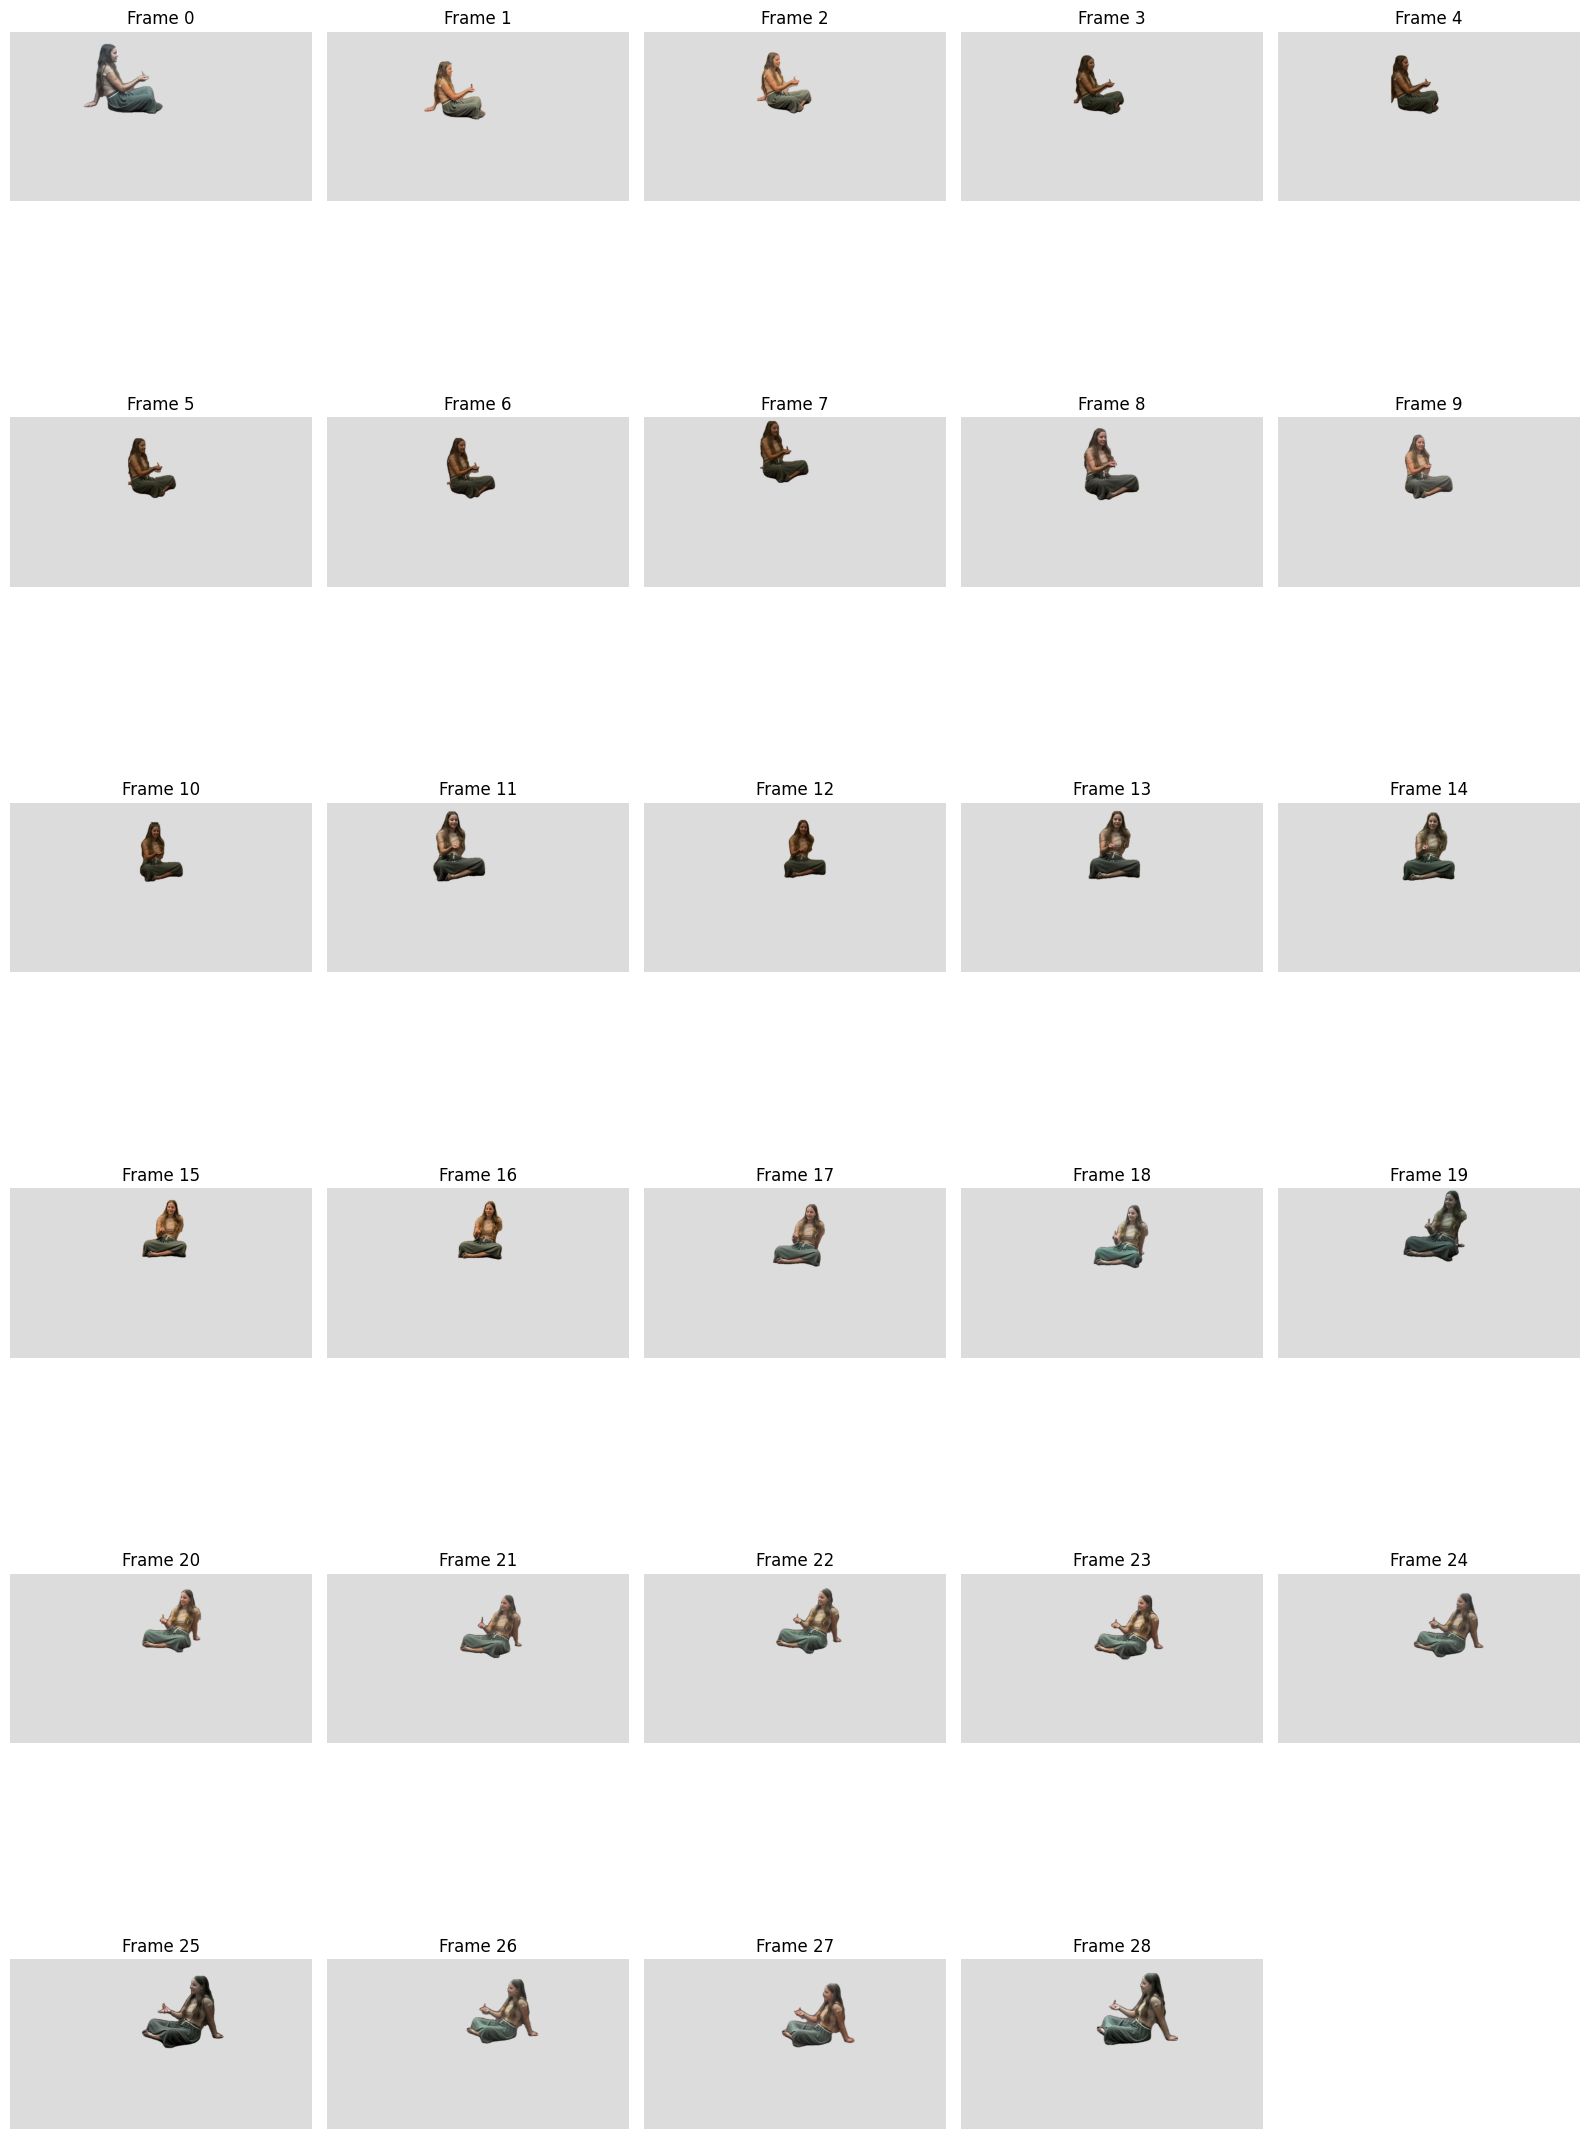

In [ ]:
# ==========================================================
# CAMERA CONTACT SHEET
# ==========================================================

import matplotlib.pyplot as plt
import math

cols = 5
rows = math.ceil(len(master_frames) / cols)

plt.figure(figsize=(16, rows * 4))

for i, frame in enumerate(master_frames):

    plt.subplot(rows, cols, i + 1)

    # checker/white background makes unwanted mask pieces visible
    rgba = np.array(frame.convert("RGBA"))

    background = np.ones(
        (rgba.shape[0], rgba.shape[1], 3),
        dtype=np.uint8
    ) * 220

    a = rgba[:, :, 3:4] / 255.0

    composite = (
        rgba[:, :, :3] * a
        + background * (1-a)
    ).astype(np.uint8)

    plt.imshow(composite)

    plt.title(
        f"Frame {i}"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

## 10. Use real cameras only (no optical-flow interpolation)

In [ ]:
!pip install -q scikit-video

In [ ]:
import skvideo.io
print("skvideo OK")

skvideo OK


In [ ]:
%cd /content/ECCV2022-RIFE

!rm -rf train_log
!mkdir -p train_log

!pip install -q gdown

!gdown --fuzzy "https://drive.google.com/file/d/1APIzVeI-4ZZCEuIRE1m6WYfSCaOsi_7_/view?usp=sharing" \
    -O /content/rife_hd.zip

/content/ECCV2022-RIFE
Downloading...
From: https://drive.google.com/uc?id=1APIzVeI-4ZZCEuIRE1m6WYfSCaOsi_7_
To: /content/rife_hd.zip
100% 11.3M/11.3M [00:00<00:00, 81.9MB/s]


In [ ]:
from pathlib import Path

p = Path("/content/rife_hd.zip")

print("exists:", p.exists())
print("size MB:", round(p.stat().st_size / 1e6, 2))

exists: True
size MB: 11.33


In [ ]:
!unzip -q /content/rife_hd.zip -d /content/rife_weights

!find /content/rife_weights -maxdepth 3 -type f | head -30

replace /content/rife_weights/train_log/.DS_Store? [y]es, [n]o, [A]ll, [N]one, [r]ename: N
/content/rife_weights/train_log/flownet.pkl
/content/rife_weights/train_log/RIFE_HDv3.py
/content/rife_weights/train_log/.DS_Store
/content/rife_weights/train_log/__pycache__/RIFE_HDv3.cpython-37.pyc
/content/rife_weights/train_log/__pycache__/IFNet_HDv3.cpython-37.pyc
/content/rife_weights/train_log/IFNet_HDv3.py
/content/rife_weights/__MACOSX/train_log/._.DS_Store
/content/rife_weights/__MACOSX/train_log/._RIFE_HDv3.py
/content/rife_weights/__MACOSX/train_log/._IFNet_HDv3.py
/content/rife_weights/__MACOSX/._train_log


In [ ]:
import shutil
from pathlib import Path

src_root = Path("/content/rife_weights")
dst = Path("/content/ECCV2022-RIFE/train_log")

for f in src_root.rglob("*.pkl"):
    print("copying:", f)
    shutil.copy2(f, dst / f.name)

print("\ntrain_log contents:")
for f in dst.glob("*"):
    print(f.name)

copying: /content/rife_weights/train_log/flownet.pkl

train_log contents:
flownet.pkl


In [ ]:
weight = Path(
    "/content/ECCV2022-RIFE/train_log/flownet.pkl"
)

print("flownet.pkl exists:", weight.exists())

flownet.pkl exists: True


In [ ]:
# ==========================================================
# CLEAN PRACTICAL-RIFE SETUP
# ==========================================================

%cd /content

!rm -rf Practical-RIFE
!git clone -q https://github.com/hzwer/Practical-RIFE.git

%cd /content/Practical-RIFE

!pip install -q torch torchvision opencv-python tqdm

/content
/content/Practical-RIFE


In [ ]:
!find /content/Practical-RIFE -maxdepth 2 -type f | head -80

/content/Practical-RIFE/inference_img.py
/content/Practical-RIFE/.gitignore
/content/Practical-RIFE/.git/description
/content/Practical-RIFE/.git/packed-refs
/content/Practical-RIFE/.git/HEAD
/content/Practical-RIFE/.git/config
/content/Practical-RIFE/.git/index
/content/Practical-RIFE/README.md
/content/Practical-RIFE/inference_video.py
/content/Practical-RIFE/model/warplayer.py
/content/Practical-RIFE/model/loss.py
/content/Practical-RIFE/LICENSE
/content/Practical-RIFE/inference_img_SR.py
/content/Practical-RIFE/inference_video_enhance.py
/content/Practical-RIFE/demo/i0.png
/content/Practical-RIFE/demo/i1.png
/content/Practical-RIFE/demo/I0_1.png
/content/Practical-RIFE/demo/I0_slomo_clipped.gif
/content/Practical-RIFE/demo/I2_0.png
/content/Practical-RIFE/demo/I0_0.png
/content/Practical-RIFE/demo/I2_slomo_clipped.gif
/content/Practical-RIFE/demo/I2_1.png
/content/Practical-RIFE/requirements.txt


In [ ]:
# ==========================================================
# DOWNLOAD MATCHING PRACTICAL-RIFE v4.25 LITE MODEL
# ==========================================================

%cd /content/Practical-RIFE

!rm -rf train_log
!mkdir -p train_log

!pip install -q gdown

!gdown --fuzzy \
"https://drive.google.com/file/d/1zlKblGuKNatulJNFf5jdB-emp9AqGK05/view?usp=share_link" \
-O /content/rife425lite.zip

!rm -rf /content/rife425lite
!mkdir -p /content/rife425lite

!unzip -q /content/rife425lite.zip -d /content/rife425lite

/content/Practical-RIFE
Downloading...
From: https://drive.google.com/uc?id=1zlKblGuKNatulJNFf5jdB-emp9AqGK05
To: /content/rife425lite.zip
100% 22.8M/22.8M [00:00<00:00, 230MB/s]


In [ ]:
!find /content/rife425lite -maxdepth 4 -type f | head -50

/content/rife425lite/train_log/flownet.pkl
/content/rife425lite/train_log/RIFE_HDv3.py
/content/rife425lite/train_log/refine.py
/content/rife425lite/train_log/.DS_Store
/content/rife425lite/train_log/__pycache__/IFNet_HDv3.cpython-311.pyc
/content/rife425lite/train_log/__pycache__/RIFE_HDv3.cpython-311.pyc
/content/rife425lite/train_log/IFNet_HDv3.py
/content/rife425lite/__MACOSX/train_log/._flownet.pkl
/content/rife425lite/__MACOSX/train_log/._.DS_Store
/content/rife425lite/__MACOSX/train_log/._refine.py
/content/rife425lite/__MACOSX/._train_log


In [ ]:
from pathlib import Path
import shutil

src = Path("/content/rife425lite")
dst = Path("/content/Practical-RIFE/train_log")

for f in src.rglob("*"):
    if f.is_file() and f.suffix.lower() in [".py", ".pkl"]:
        print("copy:", f.name)
        shutil.copy2(f, dst / f.name)

print("\ntrain_log:")
for f in sorted(dst.iterdir()):
    print(f.name)

copy: flownet.pkl
copy: RIFE_HDv3.py
copy: refine.py
copy: IFNet_HDv3.py
copy: ._flownet.pkl
copy: ._refine.py

train_log:
._flownet.pkl
._refine.py
IFNet_HDv3.py
RIFE_HDv3.py
flownet.pkl
refine.py


In [ ]:
from pathlib import Path

print(
    "flownet:",
    Path("/content/Practical-RIFE/train_log/flownet.pkl").exists()
)

print(
    "model python files:",
    list(Path("/content/Practical-RIFE/train_log").glob("*.py"))
)

flownet: True
model python files: [PosixPath('/content/Practical-RIFE/train_log/RIFE_HDv3.py'), PosixPath('/content/Practical-RIFE/train_log/refine.py'), PosixPath('/content/Practical-RIFE/train_log/._refine.py'), PosixPath('/content/Practical-RIFE/train_log/IFNet_HDv3.py')]


In [ ]:
# ==========================================================
# EXACT CONSTANT HEIGHT FROM EXISTING PERSON MASKS
# ==========================================================

import numpy as np
import cv2
from PIL import Image

# Reorder masks in the SAME order as master_frames
ordered_person_masks = [
    human_masks[i]
    for i in order
]

ordered_cutouts = [
    cutouts[i]
    for i in order
]


def mask_geometry(mask):

    ys, xs = np.where(mask > 40)

    if len(xs) == 0:
        return None

    x1 = float(xs.min())
    x2 = float(xs.max())
    y1 = float(ys.min())
    y2 = float(ys.max())

    return {
        "cx": 0.5 * (x1 + x2),
        "bottom": y2,
        "height": y2 - y1 + 1
    }


geometries = [
    mask_geometry(mask)
    for mask in ordered_person_masks
]

if any(g is None for g in geometries):
    raise RuntimeError(
        "Could not measure person height in one or more masks."
    )


TARGET_PERSON_HEIGHT = float(
    np.median([
        g["height"]
        for g in geometries
    ])
)

TARGET_BOTTOM = float(
    np.median([
        g["bottom"]
        for g in geometries
    ])
)

TARGET_CX = float(
    np.median([
        g["cx"]
        for g in geometries
    ])
)

frame_w, frame_h = ordered_cutouts[0].size

constant_height_frames = []


for frame, g in zip(
    ordered_cutouts,
    geometries
):

    scale = (
        TARGET_PERSON_HEIGHT
        / g["height"]
    )

    tx = (
        TARGET_CX
        - scale * g["cx"]
    )

    ty = (
        TARGET_BOTTOM
        - scale * g["bottom"]
    )

    M = np.array(
        [
            [scale, 0, tx],
            [0, scale, ty]
        ],
        dtype=np.float32
    )

    rgba = np.array(
        frame.convert("RGBA")
    )

    corrected = cv2.warpAffine(
        rgba,
        M,
        (frame_w, frame_h),
        flags=cv2.INTER_LANCZOS4,
        borderMode=cv2.BORDER_CONSTANT,
        borderValue=(0, 0, 0, 0)
    )

    constant_height_frames.append(
        Image.fromarray(corrected)
    )


master_frames = constant_height_frames

print(
    "Exact constant-height frames:",
    len(master_frames)
)

print(
    "Target person height:",
    round(TARGET_PERSON_HEIGHT, 2),
    "px"
)

Exact constant-height frames: 29
Target person height: 403.0 px


In [ ]:
# ==========================================================
# REBUILD RIFE INPUT FROM CURRENT MASTER_FRAMES
# ==========================================================

from pathlib import Path
import shutil
import numpy as np
from PIL import Image

RIFE_INPUT_DIR = Path("/content/rife_input")

shutil.rmtree(
    RIFE_INPUT_DIR,
    ignore_errors=True
)

RIFE_INPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

rife_alpha_frames = []

for i, frame in enumerate(master_frames):

    rgba = np.array(
        frame.convert("RGBA")
    )

    rgb = rgba[:, :, :3]
    alpha = rgba[:, :, 3]

    # Keep alpha separately
    rife_alpha_frames.append(
        Image.fromarray(alpha)
    )

    # Composite foreground onto black for RIFE
    alpha_f = (
        alpha.astype(np.float32)
        / 255.0
    )[..., None]

    rgb_black = (
        rgb.astype(np.float32)
        * alpha_f
    )

    rgb_black = np.clip(
        rgb_black,
        0,
        255
    ).astype(np.uint8)

    Image.fromarray(
        rgb_black
    ).save(
        RIFE_INPUT_DIR / f"{i:04d}.png"
    )


# Verify before allowing RIFE to run
input_files = sorted(
    RIFE_INPUT_DIR.glob("*.png")
)

print(
    "RIFE input frames:",
    len(input_files)
)

print(
    "RIFE input directory:",
    RIFE_INPUT_DIR
)

assert len(input_files) == len(master_frames), (
    f"Expected {len(master_frames)} RIFE inputs, "
    f"but found {len(input_files)}."
)

print("✓ RIFE input ready")

RIFE input frames: 29
RIFE input directory: /content/rife_input
✓ RIFE input ready


In [ ]:
%cd /content/Practical-RIFE

!pip install -q scikit-video

!rm -rf output

!python inference_video.py \
    --multi=2 \
    --img=/content/rife_input \
    --png

/content/Practical-RIFE
Loaded 3.x/4.x HD model.
 97% 28/29 [00:18<00:00,  1.52it/s]


In [ ]:
import glob

rife_files = glob.glob(
    "/content/Practical-RIFE/vid_out/*.png"
)

print("RIFE output frames:", len(rife_files))

RIFE output frames: 57


In [ ]:
from pathlib import Path
from PIL import Image

rife_files = sorted(
    Path("/content/Practical-RIFE/vid_out").glob("*.png")
)

rife_rgb_frames = [
    Image.open(f).convert("RGB")
    for f in rife_files
]

print("Loaded RIFE RGB frames:", len(rife_rgb_frames))

Loaded RIFE RGB frames: 57


In [ ]:
!rm -rf /content/Practical-RIFE/vid_out

In [ ]:
# ==========================================================
# SINGLE-SOURCE DEPTH WARP
# ==========================================================

DEPTH_SHIFT_PX = 16.0
INTERMEDIATE_VIEWS = 7


def depth_warp_single(frame, depth, fraction, direction):

    rgba = np.array(
        frame.convert("RGBA")
    )

    h, w = rgba.shape[:2]

    yy, xx = np.mgrid[
        0:h,
        0:w
    ].astype(np.float32)

    displacement = (
        direction
        * DEPTH_SHIFT_PX
        * fraction
        * depth
    ).astype(np.float32)

    map_x = (
        xx - displacement
    ).astype(np.float32)

    map_y = yy.astype(np.float32)

    warped = cv2.remap(
        rgba,
        map_x,
        map_y,
        interpolation=cv2.INTER_LINEAR,
        borderMode=cv2.BORDER_CONSTANT,
        borderValue=(0, 0, 0, 0)
    )

    return Image.fromarray(
        warped,
        "RGBA"
    )

In [ ]:
# ==========================================================
# MATRIX-STYLE DENSE HALF-FRAME INTERPOLATION
# ==========================================================

HALF_FRAMES = 11
# 11 intermediate stages between each pair.
# Try 9-15.

def ease_in_out(t):
    # smoothstep
    return t * t * (3.0 - 2.0 * t)


def matrix_half_frame(A_img, B_img, t):

    t = ease_in_out(t)

    A = np.array(
        A_img.convert("RGBA"),
        dtype=np.float32
    )

    B = np.array(
        B_img.convert("RGBA"),
        dtype=np.float32
    )

    # --------------------------------------------
    # Use alpha-aware premultiplied blending
    # --------------------------------------------

    alphaA = A[:, :, 3:4] / 255.0
    alphaB = B[:, :, 3:4] / 255.0

    premulA = A[:, :, :3] * alphaA
    premulB = B[:, :, :3] * alphaB

    alpha = (
        (1.0 - t) * alphaA
        + t * alphaB
    )

    premul = (
        (1.0 - t) * premulA
        + t * premulB
    )

    rgb = np.zeros_like(premul)

    valid = alpha > 1e-5

    rgb = np.divide(
        premul,
        np.maximum(alpha, 1e-5),
        out=rgb,
        where=valid
    )

    out = np.dstack([
        np.clip(rgb, 0, 255),
        np.clip(alpha * 255.0, 0, 255)
    ]).astype(np.uint8)

    return Image.fromarray(
        out,
        "RGBA"
    )


matrix_frames = []

for i in range(len(master_frames) - 1):

    A = master_frames[i]
    B = master_frames[i + 1]

    matrix_frames.append(A)

    for k in range(1, HALF_FRAMES + 1):

        t = k / (HALF_FRAMES + 1)

        matrix_frames.append(
            matrix_half_frame(
                A,
                B,
                t
            )
        )


matrix_frames.append(
    master_frames[-1]
)

print(
    "Matrix-style frames:",
    len(matrix_frames)
)

/tmp/ipykernel_2202/1900960685.py:64: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  return Image.fromarray(


Matrix-style frames: 337


In [ ]:
# ==========================================================
# TEMPORAL MOTION BLUR FUNCTION
# ==========================================================

import numpy as np
from PIL import Image


def temporal_motion_blur_smooth(
    frames,
    radius=1,
    strength=0.08
):
    """
    Blend neighbouring frames slightly into each frame.

    radius:
        1 = previous/current/next
        2 = up to 2 neighbouring frames

    strength:
        amount contributed by neighbouring frames
    """

    if len(frames) == 0:
        return []

    output = []

    for i in range(len(frames)):

        current = np.array(
            frames[i].convert("RGBA"),
            dtype=np.float32
        )

        accum = current.copy()
        total_weight = 1.0

        for offset in range(1, radius + 1):

            # Weight decreases with distance
            weight = strength / offset

            # Previous frame
            j = i - offset

            if j >= 0:

                previous = np.array(
                    frames[j].convert("RGBA"),
                    dtype=np.float32
                )

                accum += previous * weight
                total_weight += weight

            # Next frame
            j = i + offset

            if j < len(frames):

                following = np.array(
                    frames[j].convert("RGBA"),
                    dtype=np.float32
                )

                accum += following * weight
                total_weight += weight

        result = (
            accum / total_weight
        )

        result = np.clip(
            result,
            0,
            255
        ).astype(np.uint8)

        output.append(
            Image.fromarray(
                result,
                "RGBA"
            )
        )

    return output


print("✓ temporal_motion_blur_smooth ready")

✓ temporal_motion_blur_smooth ready


In [ ]:
# ==========================================================
# 6. LIGHT MOTION BLUR
# ==========================================================

MOTION_BLUR_RADIUS = 1
MOTION_BLUR_STRENGTH = 0.08

final_frames = temporal_motion_blur_smooth(
    matrix_frames
)

print(
    "Final frames:",
    len(final_frames)
)

/tmp/ipykernel_2202/1642501895.py:82: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  Image.fromarray(


Final frames: 337


## 11. Export transparent PNGs + MP4 preview

In [ ]:
def save_png_sequence(frames, folder):
    shutil.rmtree(folder, ignore_errors=True)
    folder.mkdir(parents=True, exist_ok=True)
    for i, frame in enumerate(frames):
        frame.save(folder / f"frame_{i:05d}.png", compress_level=1)


def make_mp4_preview(frames, output_path):
    preview_dir = output_path.parent / "_preview_frames"
    shutil.rmtree(preview_dir, ignore_errors=True)
    preview_dir.mkdir(parents=True)

    for i, frame in enumerate(frames):
        bg = Image.new("RGBA", frame.size, (245, 245, 245, 255))
        preview = Image.alpha_composite(bg, frame.convert("RGBA")).convert("RGB")
        preview.save(preview_dir / f"frame_{i:05d}.jpg", quality=88)

    subprocess.run([
        "ffmpeg", "-y", "-loglevel", "error",
        "-framerate", str(FPS),
        "-i", str(preview_dir / "frame_%05d.jpg"),
        "-c:v", "libx264",
        "-preset", "veryfast",
        "-crf", "21",
        "-pix_fmt", "yuv420p",
        str(output_path),
    ], check=False)

    shutil.rmtree(preview_dir)


mode_dir = EXPORT_DIR / "freeze"
mode_dir.mkdir(parents=True, exist_ok=True)

save_png_sequence(
    final_frames,
    mode_dir / "png_alpha"
)

make_mp4_preview(
    final_frames,
    mode_dir / "freeze_preview.mp4"
)
records_df.to_csv(mode_dir / "detection_report.csv", index=False)

print("Preview:", mode_dir / "freeze_preview.mp4")
print("Detection report:", mode_dir / "detection_report.csv")
print("TOTAL CORE PIPELINE TIME:", round((time.time() - pipeline_start) / 60, 2), "minutes")

Preview: /content/bullet_time/exports/freeze/freeze_preview.mp4
Detection report: /content/bullet_time/exports/freeze/detection_report.csv
TOTAL CORE PIPELINE TIME: 9.17 minutes


## 12. Optional ProRes 4444 transparent video

In [ ]:
def export_prores_alpha():
    mode_dir = EXPORT_DIR / "freeze"
    input_pattern = str(mode_dir / "png_alpha" / "frame_%05d.png")
    output_path = mode_dir / "freeze_alpha_prores4444.mov"

    subprocess.run([
        "ffmpeg", "-y", "-loglevel", "error",
        "-framerate", str(FPS),
        "-i", input_pattern,
        "-c:v", "prores_ks",
        "-profile:v", "4",
        "-pix_fmt", "yuva444p10le",
        str(output_path)
    ], check=False)

    print(output_path)

# Run only when needed:
# export_prores_alpha()


## 13. Download outputs

In [ ]:
# ==========================================================
# FAST DOWNLOAD — MP4 ONLY
# ==========================================================

from google.colab import files

video_path = EXPORT_DIR / "freeze" / "freeze_preview.mp4"

print(
    "Downloading:",
    video_path
)

files.download(
    str(video_path)
)

Downloading: /content/bullet_time/exports/freeze/freeze_preview.mp4


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
archive_path = shutil.make_archive(
    str(ROOT / "bullet_time_yolo_sam_outputs"),
    "zip",
    root_dir=EXPORT_DIR
)

print(archive_path)

from google.colab import files
files.download(archive_path)


/content/bullet_time/bullet_time_yolo_sam_outputs.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

All captures

Recognising object with Gemini

# Explanation of this Colab

This version treats the person and the thrown object differently because they are different computer-vision problems.

**Person:** YOLO segmentation reliably isolates the largest person in each camera image.

**Everyday object:** Grounding DINO receives a text prompt such as `paper airplane` and detects that object independently in every camera. SAM then turns the detector box into a pixel-level mask. The object mask is clipped near the detector box so a tiny paper plane cannot accidentally expand into a table, wall, or floor region.

The two masks are merged and exported with transparency. Stabilization is calculated from the person mask only; the paper plane is deliberately excluded from the stabilization geometry because it can move far away from the body.

The first output uses all 29 real camera frames and deliberately performs no optical-flow interpolation. This is the clean diagnostic baseline. Once the 29-frame result is correct, a separate viewpoint-aware interpolation stage can be added without mixing it into object detection.